In [780]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [781]:
df=pd.read_csv("credit scoring.csv")

C:\Users\USER\AppData\Local\Temp\ipykernel_8344\2082072843.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("credit scoring.csv")


In [782]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [783]:
df.shape


(100000, 28)

In [784]:
df.isnull().sum()

ID                              0
Customer_ID                     0
Month                           0
Name                         9985
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200
Credit_Score                    0
dtype: int64

In [785]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [786]:
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [787]:
df.duplicated().sum()

0

In [788]:
df['Name'].isnull().sum()

9985

In [789]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Features:", list(numerical_features))
categorical_features = df.select_dtypes(include=['object', 'category']).columns
print("Categorical Features:", list(categorical_features))



Numerical Features: ['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Total_EMI_per_month']
Categorical Features: ['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Num_of_Loan', 'Type_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix', 'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']


In [790]:
# Convert Credit_History_Age to numeric (months) if already in numeric form
import re

def convert_credit_age(value):
    if pd.isna(value):
        return None
    years = int(re.search(r'(\d+)\s+Years', value).group(1))
    months = int(re.search(r'(\d+)\s+Months', value).group(1))
    return years * 12 + months

df['Credit_History_Age'] = df['Credit_History_Age'].apply(convert_credit_age)

# Ensure Num_of_Delayed_Payment is integer
df['Num_of_Delayed_Payment'] = pd.to_numeric(df['Num_of_Delayed_Payment'], errors='coerce').fillna(0).astype(int)

# Convert Monthly_Balance to float
df['Monthly_Balance'] = pd.to_numeric(df['Monthly_Balance'], errors='coerce').astype(float)

# Convert Amount_invested_monthly to float
df['Amount_invested_monthly'] = pd.to_numeric(df['Amount_invested_monthly'], errors='coerce').astype(float)





In [791]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Features:", list(numerical_features))
categorical_features = df.select_dtypes(include=['object', 'category']).columns
print("Categorical Features:", list(categorical_features))


Numerical Features: ['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']
Categorical Features: ['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Num_of_Loan', 'Type_of_Loan', 'Changed_Credit_Limit', 'Credit_Mix', 'Outstanding_Debt', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score']


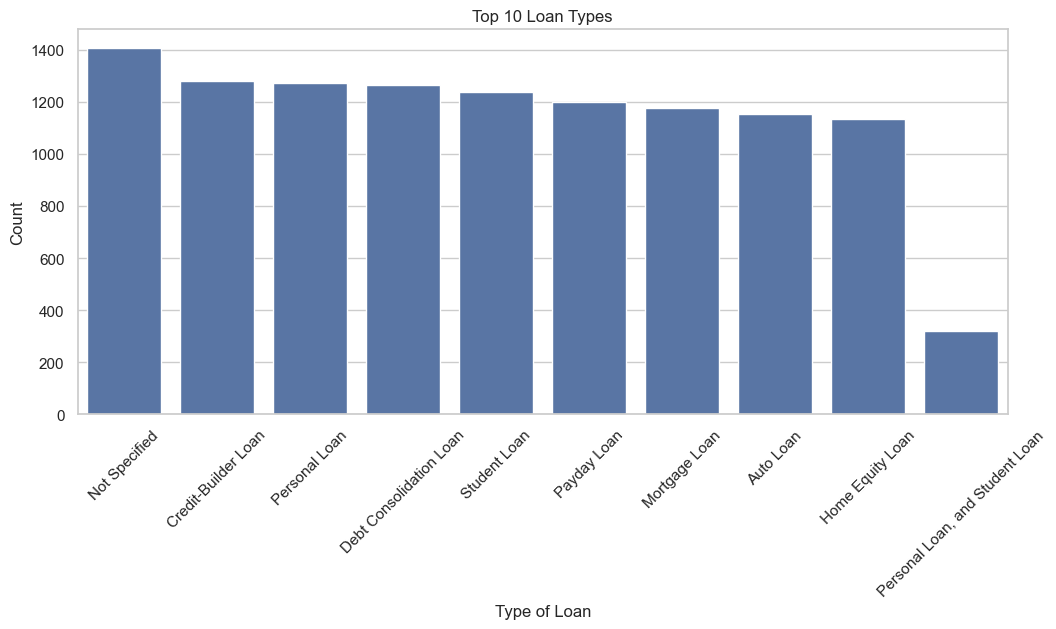

<Figure size 1200x600 with 0 Axes>

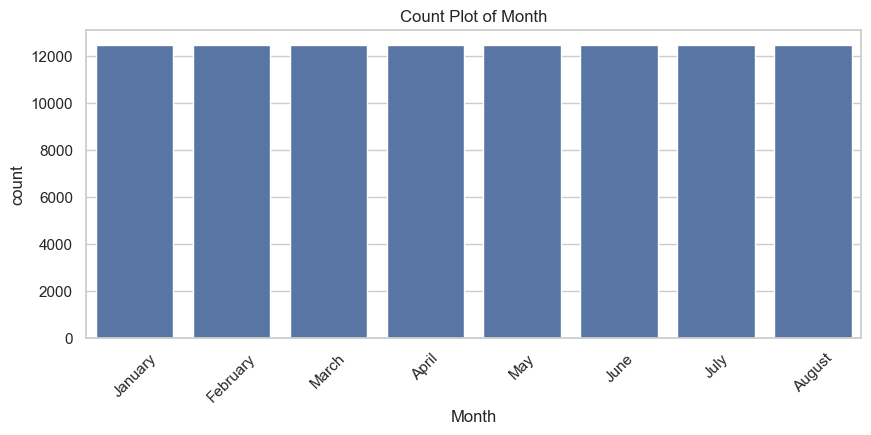

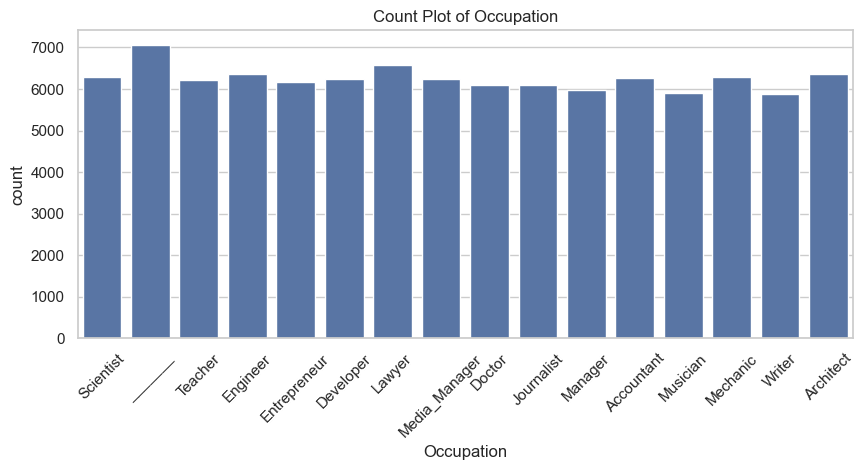

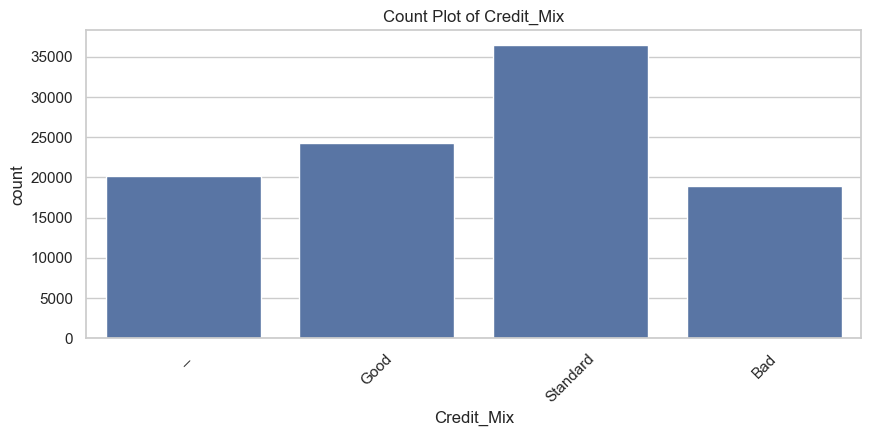

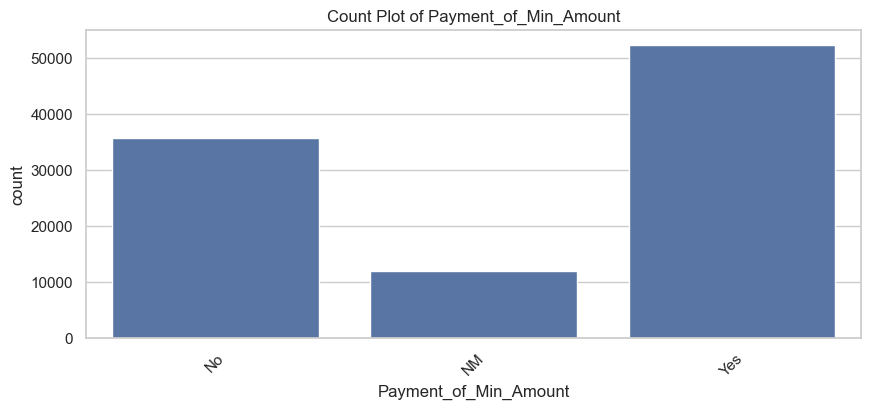

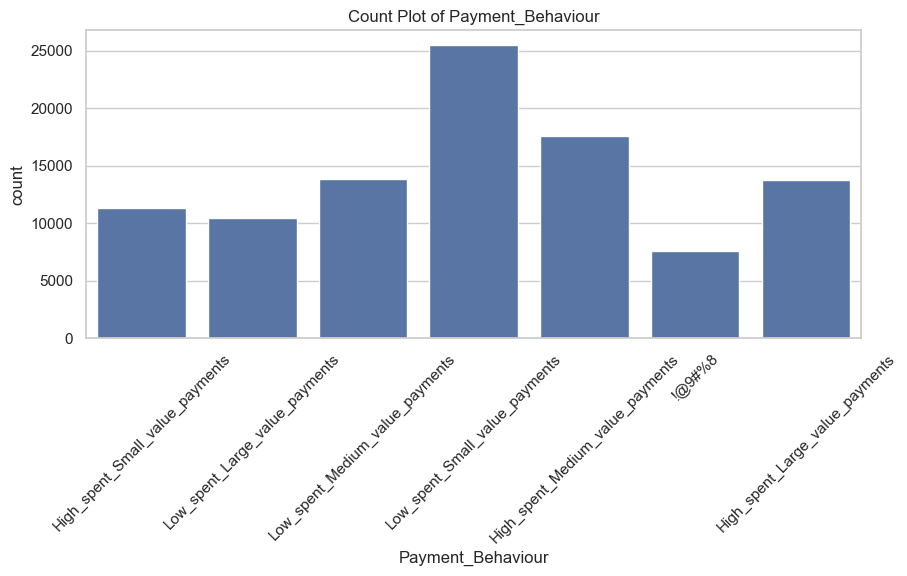

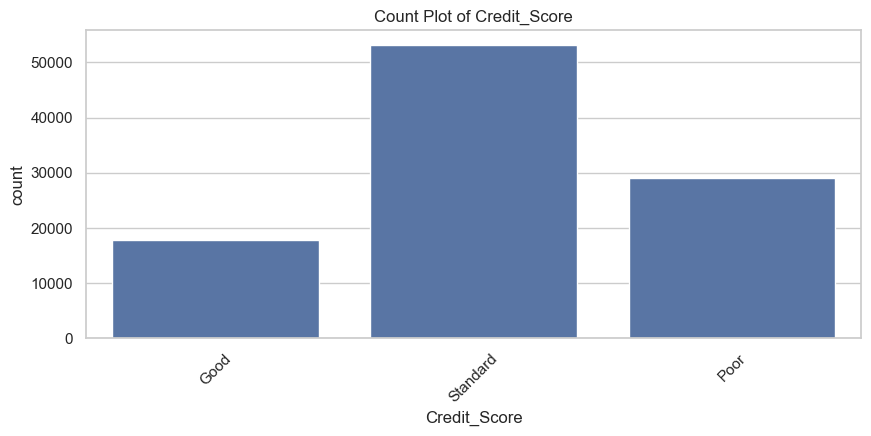

In [792]:
plt.figure(figsize=(12,5))
top10 = df['Type_of_Loan'].value_counts().head(10)

sns.barplot(x=top10.index, y=top10.values)
plt.title("Top 10 Loan Types")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.xlabel("Type of Loan")
plt.show()



cat_cols = [
    'Month', 
    'Occupation', 
    
     
    'Credit_Mix',
    'Payment_of_Min_Amount', 
    'Payment_Behaviour',
    'Credit_Score'
]

plt.figure(figsize=(12, 6))

for col in cat_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.show()



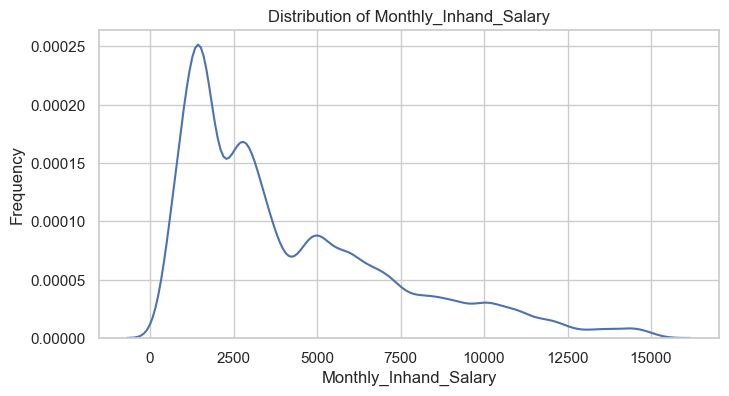

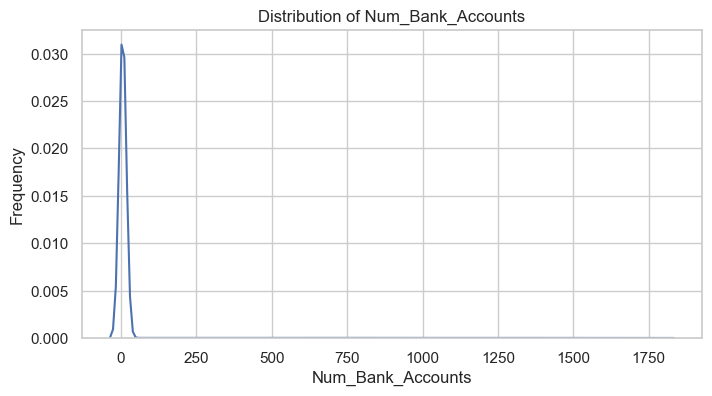

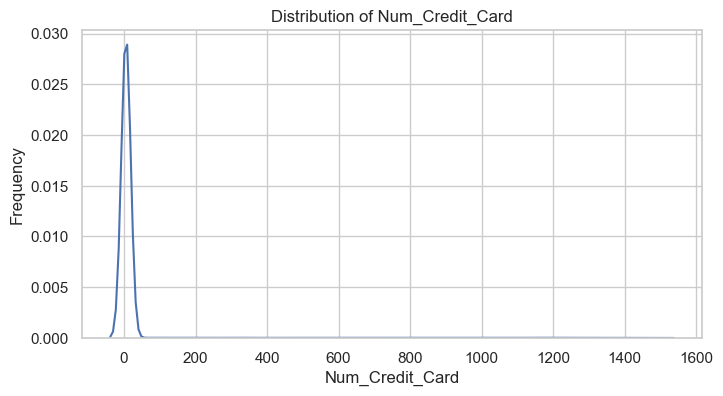

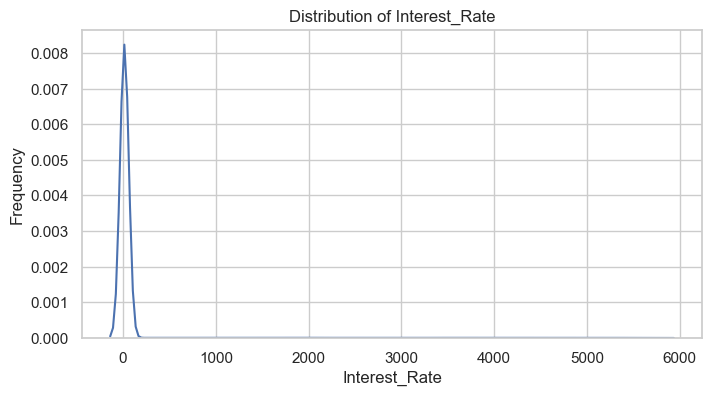

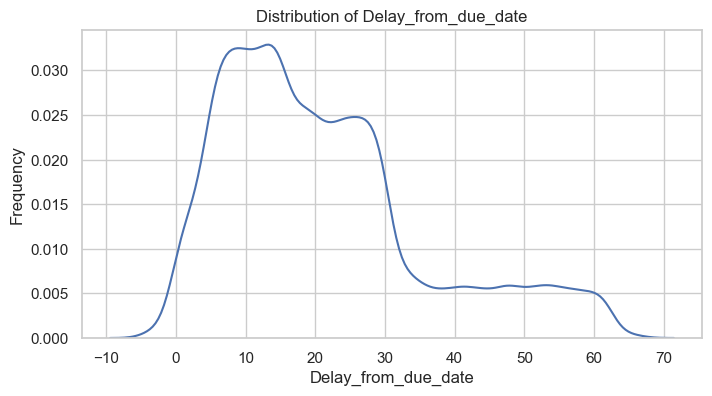

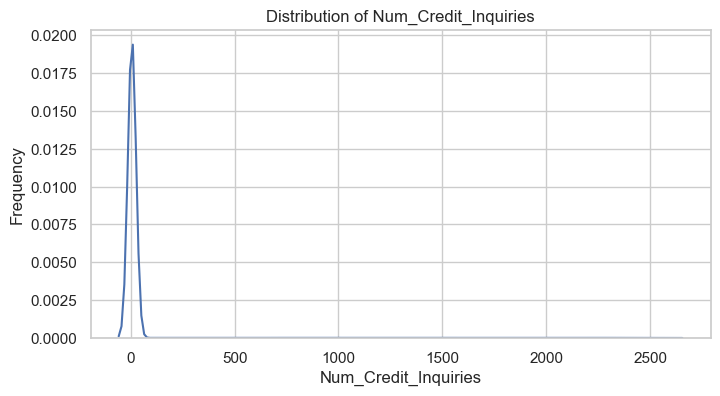

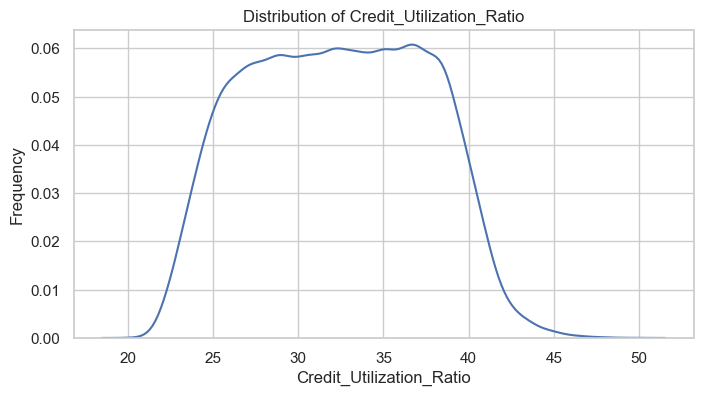

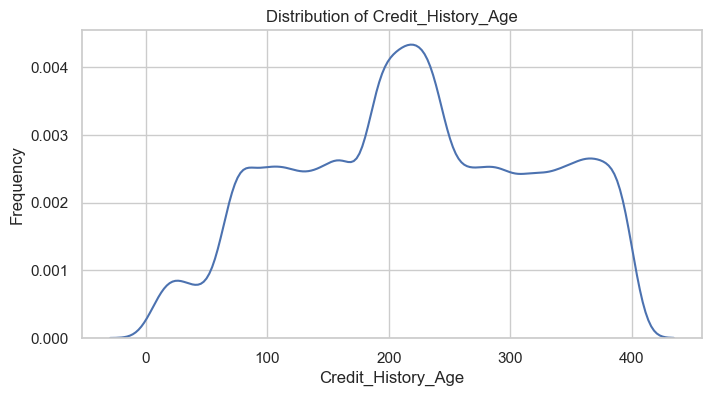

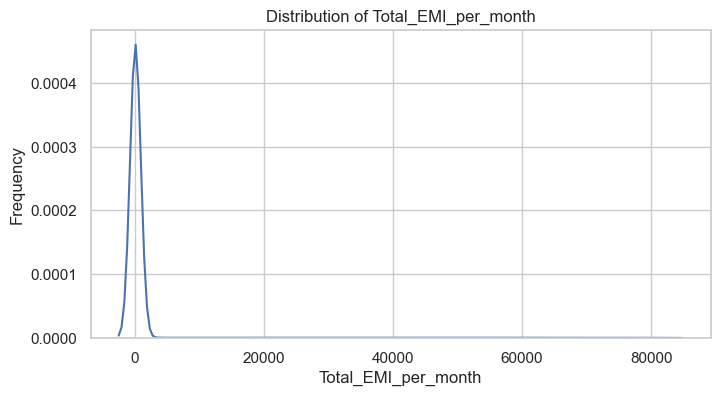

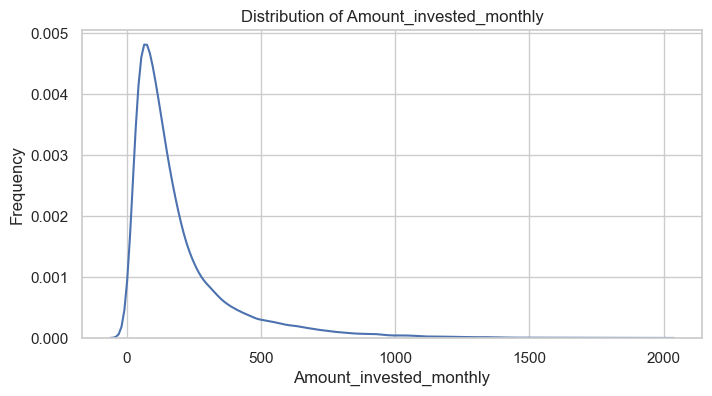

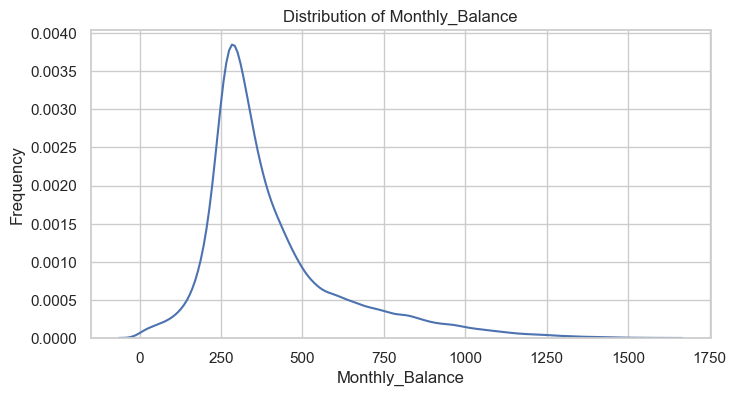

In [793]:


# Loop through all numerical features
for col in numerical_features:  # assuming you already have numerical_features list
    plt.figure(figsize=(8,4))
    sns.kdeplot(df[col])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


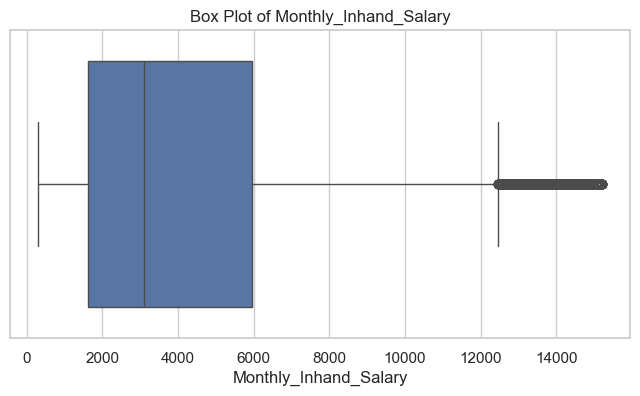

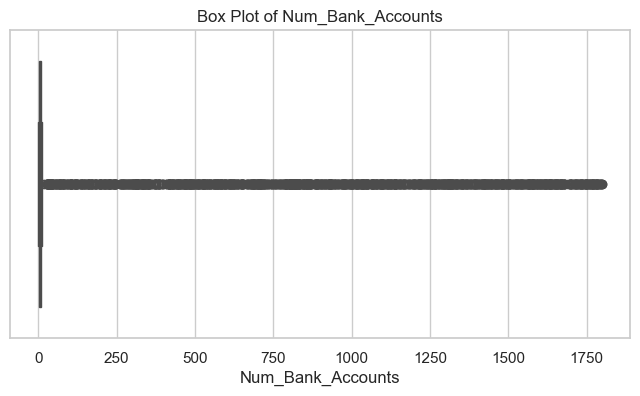

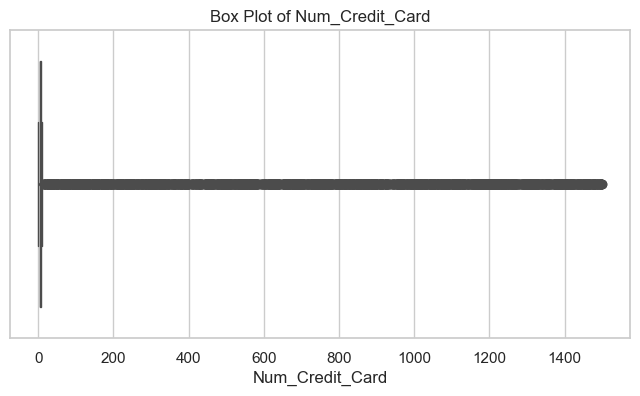

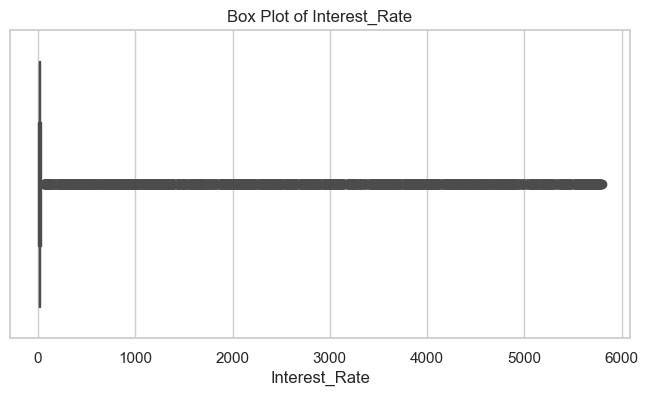

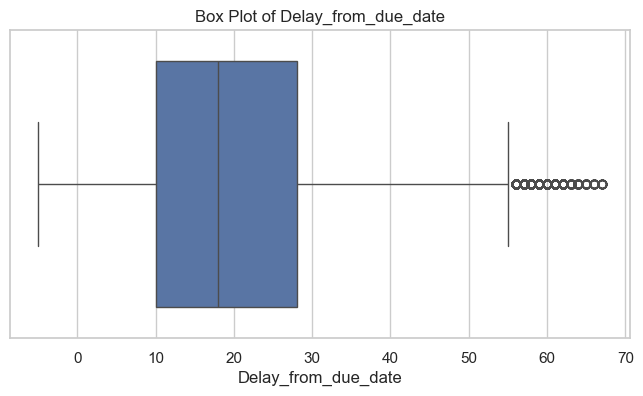

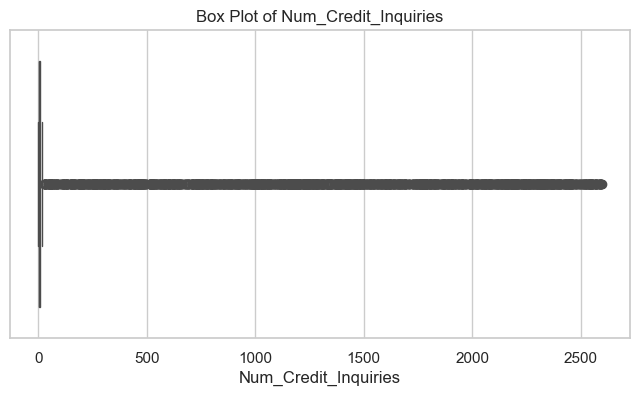

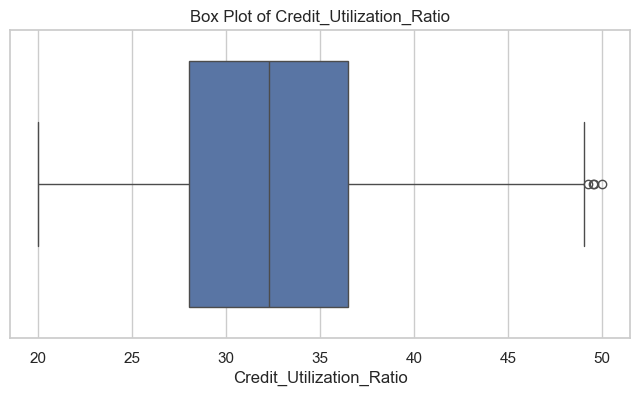

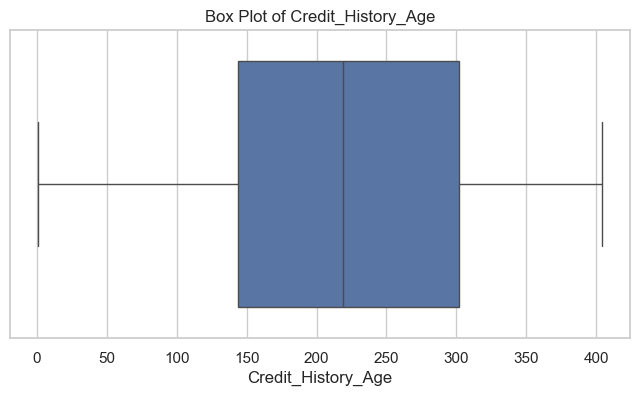

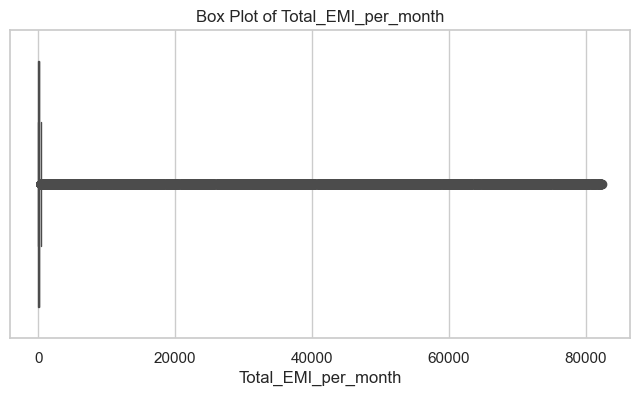

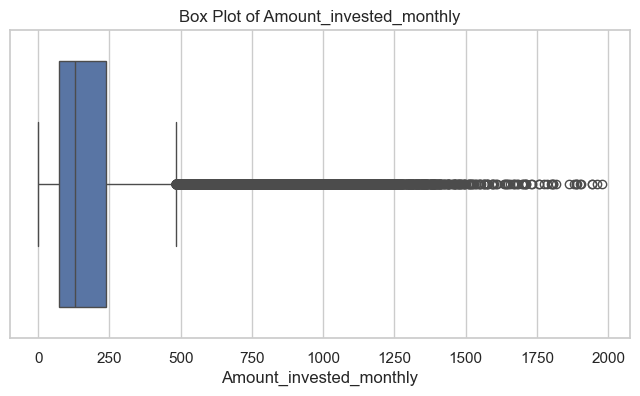

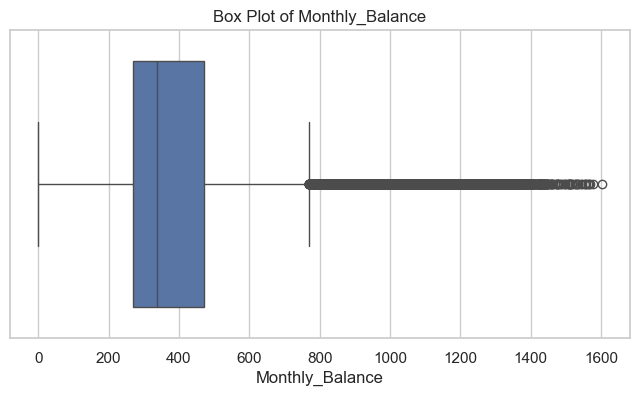

In [794]:


# Loop through each numerical feature and plot separately
for col in numerical_features:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(x=df[col])  # clip negative values if needed
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.show()


In [795]:
# Create mapping: Customer_ID → Name
name_map = df.groupby("Customer_ID")["Name"].apply(lambda x: x.dropna().iloc[0] if x.notna().any() else None)

# Fill missing names using this mapping
df["Name"] = df.apply(
    lambda row: name_map[row["Customer_ID"]] if pd.isna(row["Name"]) else row["Name"],
    axis=1
)








In [796]:
monthlysalary_map = df.groupby("Customer_ID")["Monthly_Inhand_Salary"].apply(lambda x: x.dropna().iloc[0] if x.notna().any() else None)

# Fill missing names using this mapping
df["Monthly_Inhand_Salary"] = df.apply(
    lambda row: monthlysalary_map[row["Customer_ID"]] if pd.isna(row["Monthly_Inhand_Salary"]) else row["Monthly_Inhand_Salary"],
    axis=1
)


In [797]:
df['Monthly_Inhand_Salary'].isnull().sum()

0

In [798]:
df['Type_of_Loan'].value_counts()

Type_of_Loan
Not Specified                                                                                                                         1408
Credit-Builder Loan                                                                                                                   1280
Personal Loan                                                                                                                         1272
Debt Consolidation Loan                                                                                                               1264
Student Loan                                                                                                                          1240
                                                                                                                                      ... 
Not Specified, Mortgage Loan, Auto Loan, and Payday Loan                                                                                 8
Payday Loan, M

In [799]:
df.groupby('Customer_ID')['Type_of_Loan'].unique()


Customer_ID
CUS_0x1000          [Credit-Builder Loan, and Home Equity Loan]
CUS_0x1009    [Not Specified, Home Equity Loan, Credit-Build...
CUS_0x100b                                                [nan]
CUS_0x1011    [Student Loan, Credit-Builder Loan, and Debt C...
CUS_0x1013    [Student Loan, Debt Consolidation Loan, and Pe...
                                    ...                        
CUS_0xff3         [Personal Loan, Mortgage Loan, and Auto Loan]
CUS_0xff4     [Not Specified, Student Loan, Student Loan, Cr...
CUS_0xff6                     [Home Equity Loan, and Auto Loan]
CUS_0xffc     [Credit-Builder Loan, Payday Loan, Not Specifi...
CUS_0xffd     [Auto Loan, Payday Loan, Payday Loan, Mortgage...
Name: Type_of_Loan, Length: 12500, dtype: object

In [800]:
df["Type_of_Loan"].isnull().sum()

11408

In [801]:
df['Type_of_Loan'].fillna(df['Type_of_Loan'].mode()[0], inplace=True)


C:\Users\USER\AppData\Local\Temp\ipykernel_8344\2895518561.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Type_of_Loan'].fillna(df['Type_of_Loan'].mode()[0], inplace=True)


In [802]:
df['Type_of_Loan'].isnull().sum()

0

In [803]:
df['Num_of_Delayed_Payment'].head()

0    7
1    0
2    7
3    4
4    0
Name: Num_of_Delayed_Payment, dtype: int32

In [804]:
df['Num_of_Delayed_Payment'] = df.groupby('Customer_ID')['Num_of_Delayed_Payment'] \
                                   .transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))

df['Num_of_Delayed_Payment'].isnull().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_8344\3084928240.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))


0

In [805]:
df['Num_Credit_Inquiries'].isnull().sum()

1965

In [806]:
df['Num_Credit_Inquiries'].head()


0    4.0
1    4.0
2    4.0
3    4.0
4    4.0
Name: Num_Credit_Inquiries, dtype: float64

In [807]:
df['Num_Credit_Inquiries'].fillna(df['Num_Credit_Inquiries'].median(), inplace=True)


C:\Users\USER\AppData\Local\Temp\ipykernel_8344\1626421896.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Num_Credit_Inquiries'].fillna(df['Num_Credit_Inquiries'].median(), inplace=True)


In [808]:
df['Num_Credit_Inquiries']

0        4.0
1        4.0
2        4.0
3        4.0
4        4.0
        ... 
99995    3.0
99996    3.0
99997    3.0
99998    3.0
99999    3.0
Name: Num_Credit_Inquiries, Length: 100000, dtype: float64

In [809]:
df['Credit_History_Age'].head()

0    265.0
1      NaN
2    267.0
3    268.0
4    269.0
Name: Credit_History_Age, dtype: float64

In [810]:
df.groupby("Customer_ID")["Credit_History_Age"].nunique()


Customer_ID
CUS_0x1000    8
CUS_0x1009    7
CUS_0x100b    7
CUS_0x1011    8
CUS_0x1013    7
             ..
CUS_0xff3     7
CUS_0xff4     7
CUS_0xff6     8
CUS_0xffc     6
CUS_0xffd     8
Name: Credit_History_Age, Length: 12500, dtype: int64

In [811]:
# import re

# def convert_credit_age(value):
#     if pd.isna(value):
#         return None
#     years = int(re.search(r'(\d+)\s+Years', value).group(1))
#     months = int(re.search(r'(\d+)\s+Months', value).group(1))
#     return years * 12 + months

# df['Credit_History_Age'] = df['Credit_History_Age'].apply(convert_credit_age)



In [812]:
df['Credit_History_Age'].isnull().sum()

9030

In [813]:
df['Credit_History_Age']

0        265.0
1          NaN
2        267.0
3        268.0
4        269.0
         ...  
99995    378.0
99996    379.0
99997    380.0
99998    381.0
99999    382.0
Name: Credit_History_Age, Length: 100000, dtype: float64

In [814]:
df['Credit_History_Age'].fillna(df['Credit_History_Age'].median(), inplace=True)


In [815]:
df['Amount_invested_monthly'].isnull().sum()

8784

In [816]:
df['Amount_invested_monthly'].head(10)

0     80.415295
1    118.280222
2     81.699521
3    199.458074
4     41.420153
5     62.430172
6    178.344067
7     24.785217
8    104.291825
9     40.391238
Name: Amount_invested_monthly, dtype: float64

In [817]:
df['Amount_invested_monthly'] = pd.to_numeric(df['Amount_invested_monthly'], errors='coerce')



In [818]:
df['Amount_invested_monthly'].fillna(df['Amount_invested_monthly'].median(), inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_8344\3670205184.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Amount_invested_monthly'].fillna(df['Amount_invested_monthly'].median(), inplace=True)


In [819]:
df['Amount_invested_monthly'].isnull().sum()

0

In [820]:
df['Monthly_Balance'].head()

0    312.494089
1    284.629162
2    331.209863
3    223.451310
4    341.489231
Name: Monthly_Balance, dtype: float64

In [821]:
df['Monthly_Balance']=pd.to_numeric(df['Monthly_Balance'],errors='coerce')


In [822]:
df['Monthly_Balance'].fillna(df['Monthly_Balance'].median(),inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_8344\4052894041.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Monthly_Balance'].fillna(df['Monthly_Balance'].median(),inplace=True)


In [823]:
df['Monthly_Balance'].isnull().sum()

0

In [824]:
df.isnull().sum()

ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

In [825]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              100000 non-null  ob

In [826]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Credit_Score']=le.fit_transform(df['Credit_Score'])

In [827]:
print("Label Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label Mapping: {'Good': 0, 'Poor': 1, 'Standard': 2}



----- Bivariate Analysis: Monthly_Inhand_Salary vs Credit_Score -----



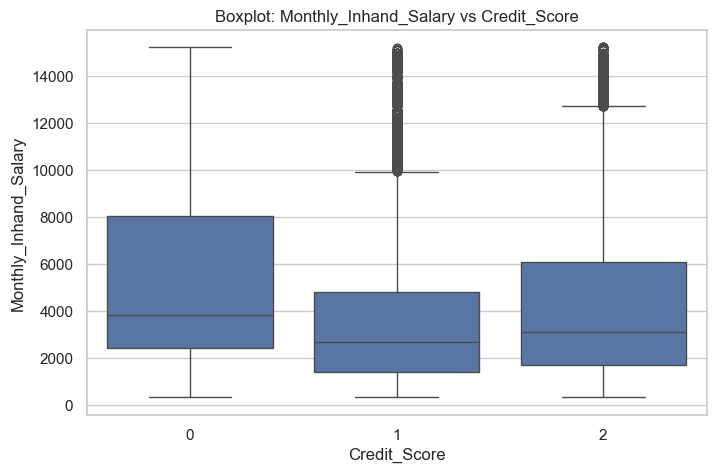


----- Bivariate Analysis: Num_Bank_Accounts vs Credit_Score -----



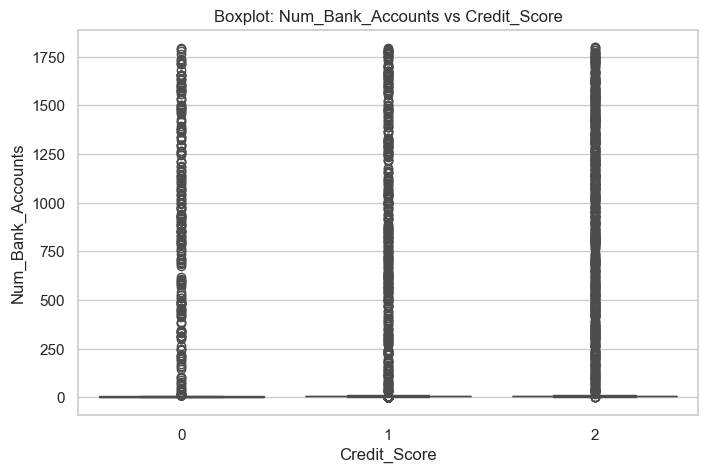


----- Bivariate Analysis: Num_Credit_Card vs Credit_Score -----



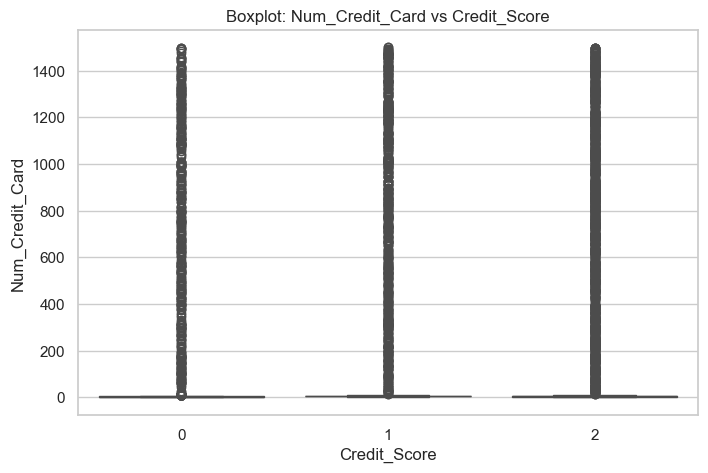


----- Bivariate Analysis: Interest_Rate vs Credit_Score -----



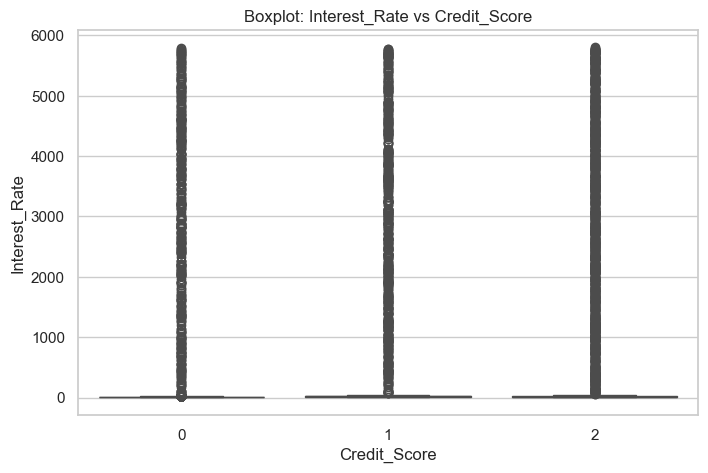


----- Bivariate Analysis: Delay_from_due_date vs Credit_Score -----



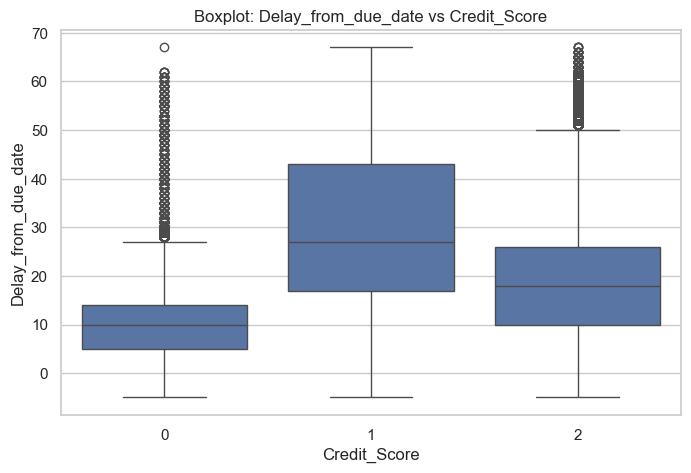


----- Bivariate Analysis: Num_Credit_Inquiries vs Credit_Score -----



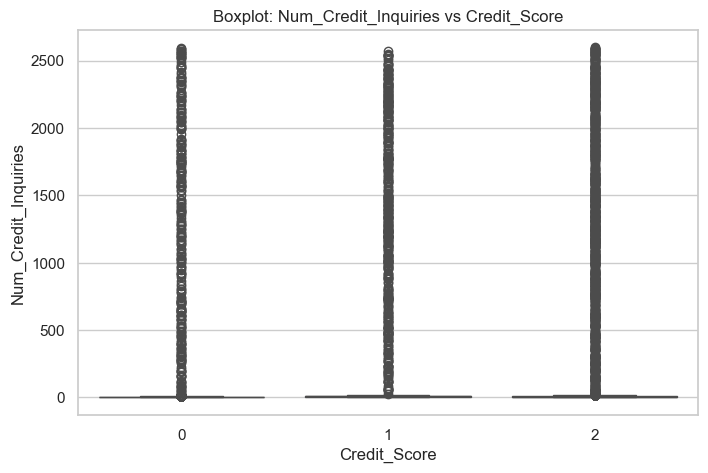


----- Bivariate Analysis: Credit_Utilization_Ratio vs Credit_Score -----



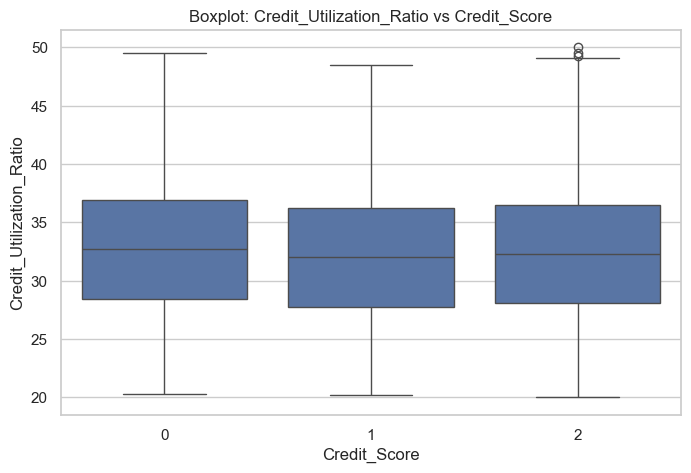


----- Bivariate Analysis: Credit_History_Age vs Credit_Score -----



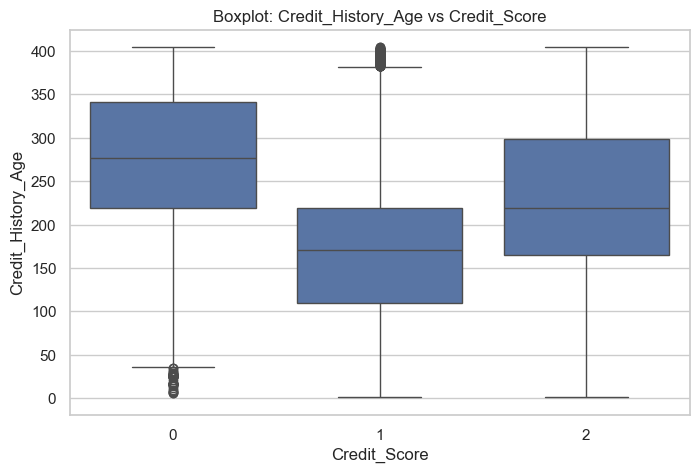


----- Bivariate Analysis: Total_EMI_per_month vs Credit_Score -----



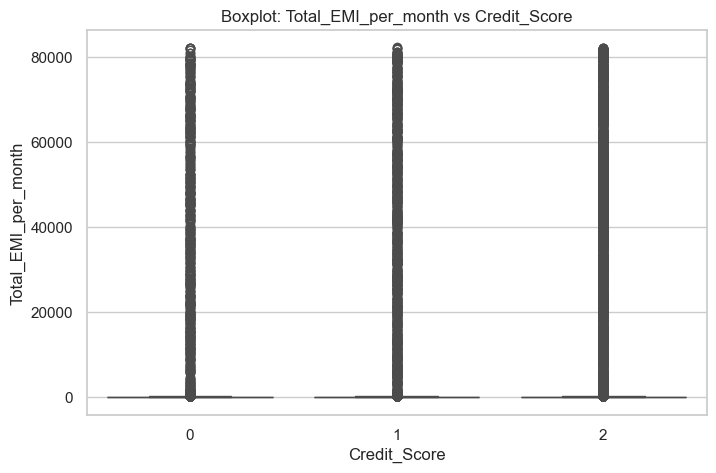


----- Bivariate Analysis: Amount_invested_monthly vs Credit_Score -----



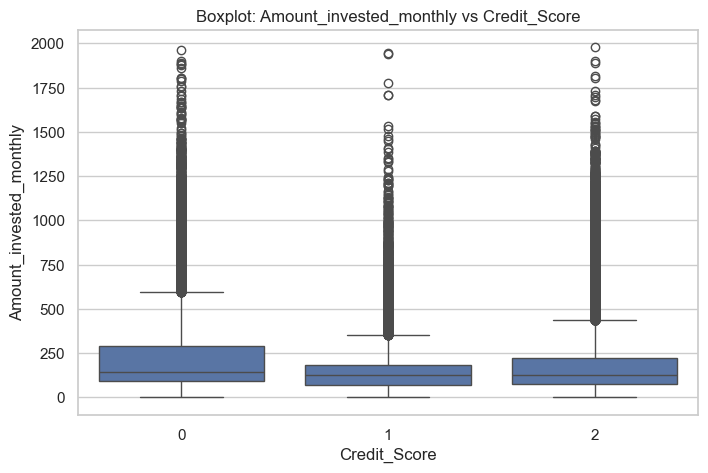


----- Bivariate Analysis: Monthly_Balance vs Credit_Score -----



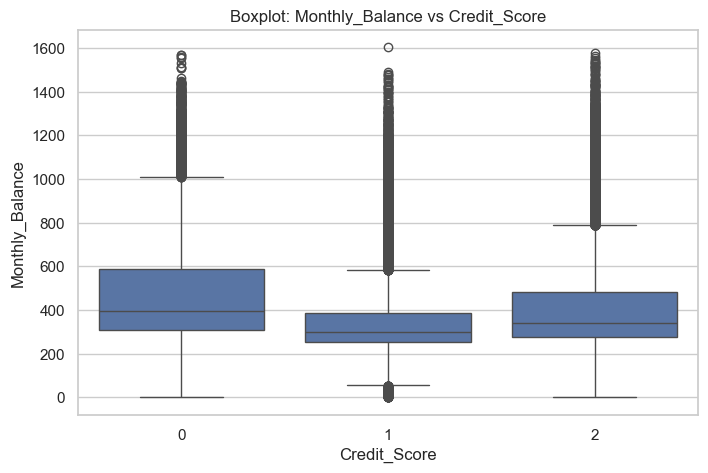

In [828]:
numerical_features= ['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 
                     'Delay_from_due_date', 'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 
                     'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 
                     'Monthly_Balance']

# Target variable
 # change here
target="Credit_Score"
# Identify numerical features automatically


# Set plot style
sns.set(style="whitegrid")

# -----------------------------
# Bivariate Analysis
# -----------------------------

for col in numerical_features:

    print(f"\n----- Bivariate Analysis: {col} vs Credit_Score -----\n")

    # 1️⃣ Boxplot
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[target], y=df[col])
    plt.title(f"Boxplot: {col} vs Credit_Score")
    plt.show()


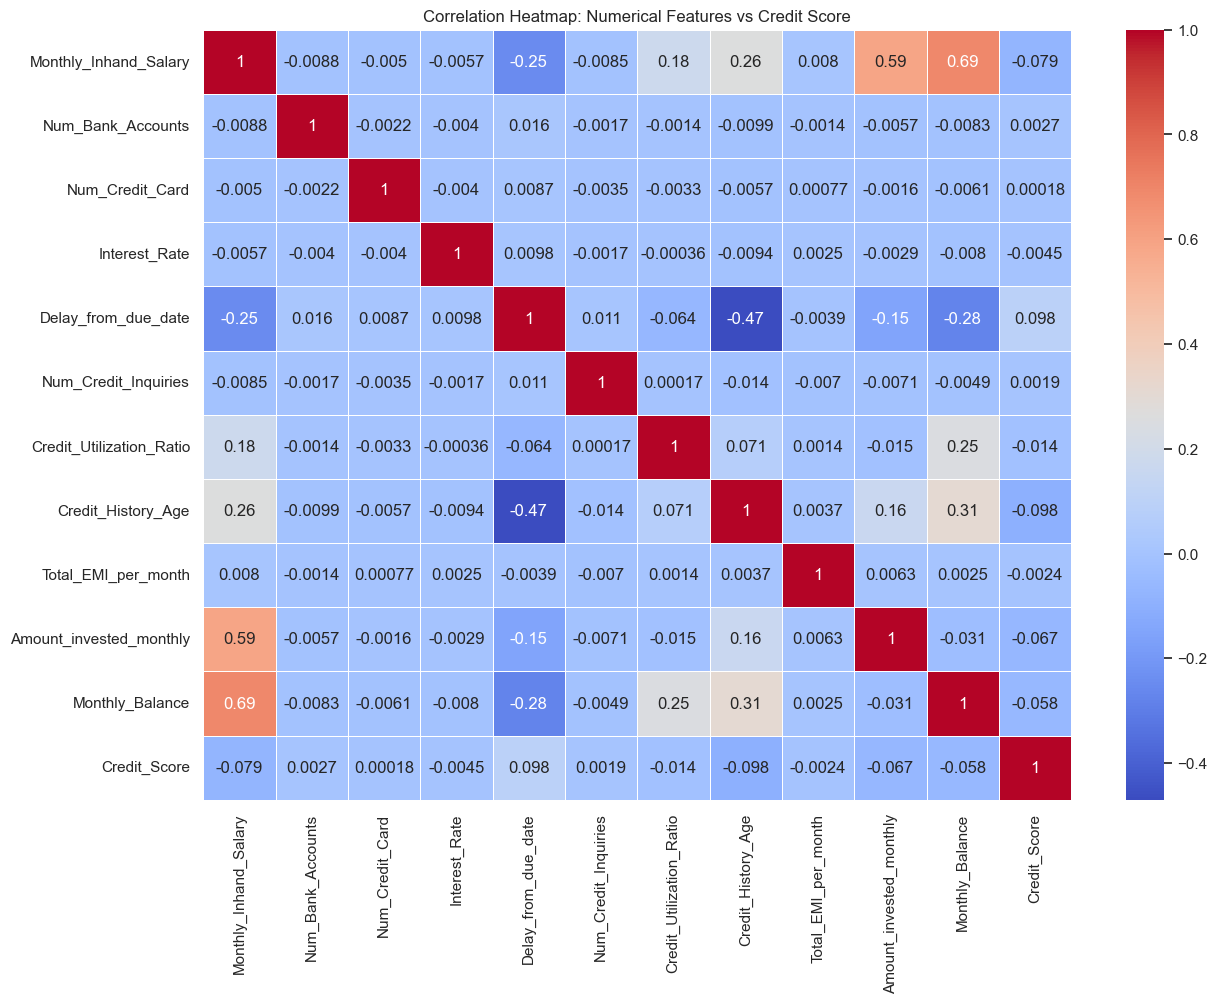

In [829]:
corr_features = numerical_features + ["Credit_Score"]

# Compute correlation matrix
corr_matrix = df[corr_features].corr()

# Plot heatmap
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap: Numerical Features vs Credit Score")
plt.show()

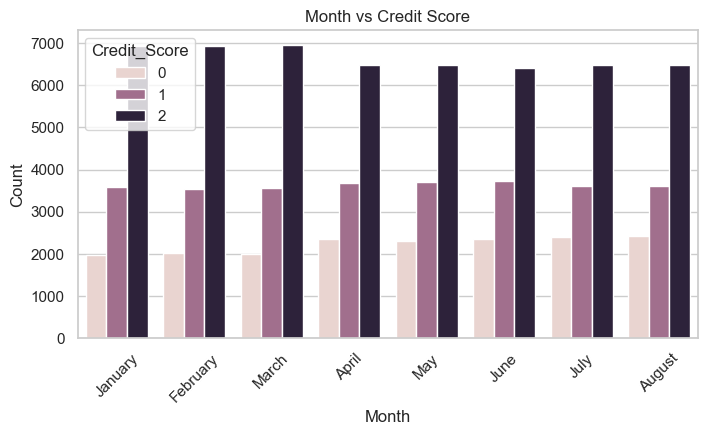

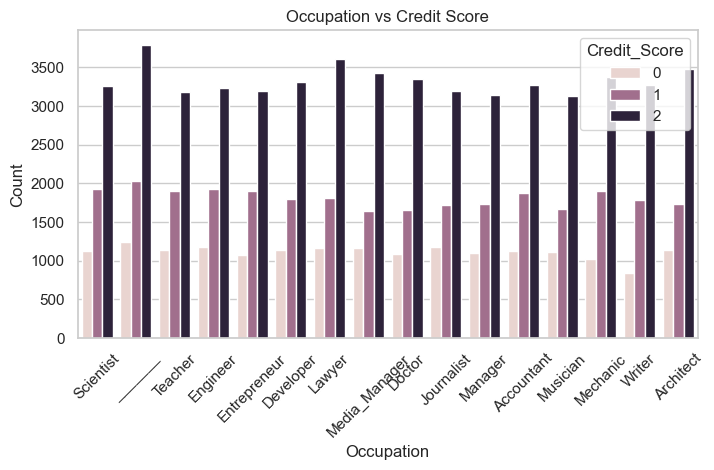

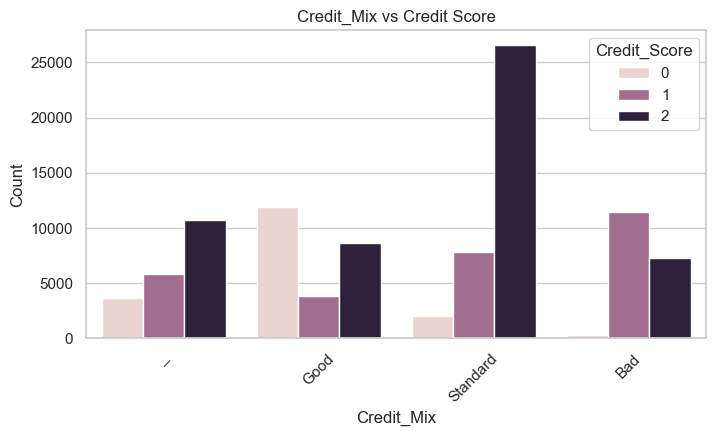

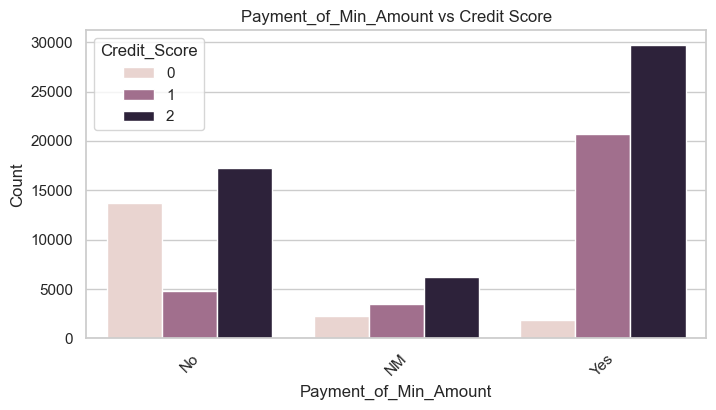

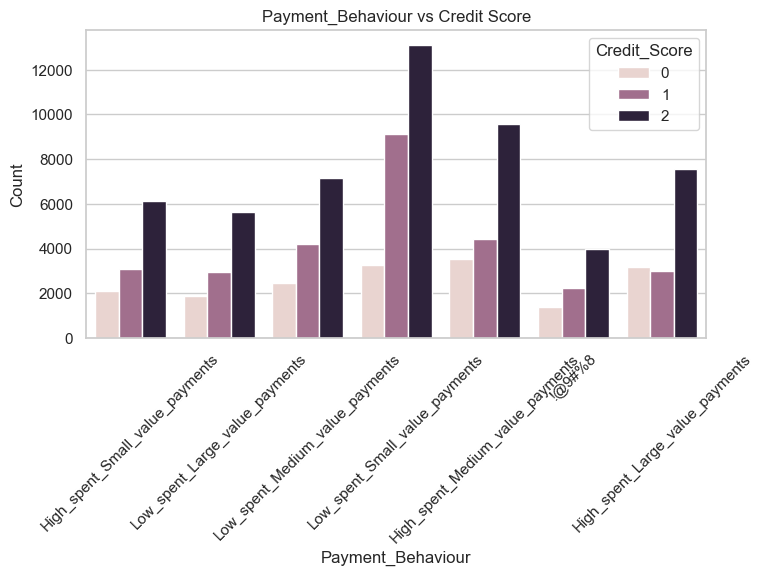

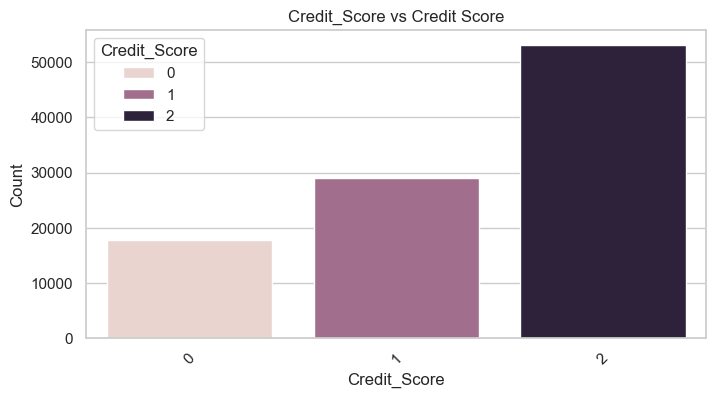

In [830]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue='Credit_Score')
    plt.title(f'{col} vs Credit Score')
    plt.xticks(rotation=45)
    plt.ylabel("Count")
    plt.xlabel(col)
    plt.show()

In [831]:
df.isnull().sum()

ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

In [832]:
numerical_features1= ['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 
                     'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 
                     'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Credit_History_Age', 
                     'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
                     'Credit_Score'] # Select only numerical features + target 


In [833]:
df[numerical_features1].dtypes

Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Delay_from_due_date           int64
Num_Credit_Inquiries        float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Monthly_Balance             float64
Credit_Score                  int32
dtype: object

In [834]:
# sns.pairplot(df[numerical_features1], hue='Credit_Score')
# plt.show()


In [835]:
df.isnull().sum()

ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

In [836]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              100000 non-null  ob

In [837]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              100000 non-null  ob

In [838]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'].isnull().sum()
df['Age'] = df.groupby('Customer_ID')['Age'].transform(lambda x: x.ffill().bfill())
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(0, Q1 - 1.5 * IQR)   # Age cannot be negative
upper_bound = Q3 + 1.5 * IQR           # Cap extreme high values

df['Age'] = df['Age'].clip(lower=lower_bound, upper=upper_bound)
df.loc[(df['Age'] < 0) | (df['Age'] > 100), 'Age'] = df['Age'].median()

df['Age'].head()

0    23.0
1    23.0
2     0.0
3    23.0
4    23.0
Name: Age, dtype: float64

In [839]:
df['Age'] = df['Age'].replace(0, np.nan)
df['Age'] = df['Age'].fillna(df['Age'].median())


In [840]:
df['Age']

0        23.0
1        23.0
2        33.0
3        23.0
4        23.0
         ... 
99995    25.0
99996    25.0
99997    25.0
99998    25.0
99999    25.0
Name: Age, Length: 100000, dtype: float64

In [841]:
df['Annual_Income']=pd.to_numeric(df['Annual_Income'],errors='coerce')
df['Annual_Income'].isnull().sum()
df['Annual_Income']=df['Annual_Income'].replace(0,np.nan)
df['Annual_Income'] = df.groupby('Customer_ID')['Annual_Income'].transform(lambda x: x.ffill().bfill())



In [842]:
df['Num_of_Loan']=pd.to_numeric(df['Num_of_Loan'],errors='coerce')
df['Num_of_Loan'].isnull().sum()
df['Num_of_Loan']=df['Num_of_Loan'].replace(0,np.nan)
df['Num_of_Loan']=df.groupby('Customer_ID')['Num_of_Loan'].transform(lambda x:x.ffill().bfill())




in this case we can fill the nan values using customer id using its fill around 1000 rows only.so we can fill balance null values with median .

In [843]:
df['Num_of_Loan'].isnull().sum()


8088

In [844]:
df['Num_of_Loan'] = df['Num_of_Loan'].fillna(df['Num_of_Loan'].median())
df['Num_of_Loan'].isnull().sum()


0

In [845]:
df['Changed_Credit_Limit']=pd.to_numeric(df['Changed_Credit_Limit'],errors='coerce')
df['Changed_Credit_Limit'].isnull().sum()
df['Changed_Credit_Limit']=df['Changed_Credit_Limit'].replace(0,np.nan)
df['Changed_Credit_Limit']=df.groupby('Customer_ID')['Changed_Credit_Limit'].transform(lambda x:x .ffill().bfill())
df['Changed_Credit_Limit'].isnull().sum()

0

In [846]:
df['Changed_Credit_Limit']=df['Changed_Credit_Limit'].clip(lower=0)

In [847]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Features:", list(numerical_features))

Numerical Features: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']


In [848]:
df['Num_of_Delayed_Payment']=df['Num_of_Delayed_Payment'].clip(lower=0,upper=18)

In [849]:


df['Num_of_Loan'] = df['Num_of_Loan'].clip(lower=0)

In [850]:
for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].apply(lambda x: upper_bound if x > upper_bound else (lower_bound if x < lower_bound else x))

print(df[numerical_features].describe())


                 Age  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  \
count  100000.000000  100000.000000          100000.000000      100000.000000   
mean       33.967950   51271.266788            4172.694122           5.467990   
std        11.601625   38712.832214            3109.365705           2.719465   
min        14.000000    7005.930000             303.645417          -1.000000   
25%        25.000000   19457.500000            1626.761667           3.000000   
50%        33.000000   37578.610000            3096.836667           6.000000   
75%        42.000000   72814.860000            5964.883333           7.000000   
max        67.500000  152850.900000           12472.065833          13.000000   

       Num_Credit_Card  Interest_Rate    Num_of_Loan  Delay_from_due_date  \
count    100000.000000  100000.000000  100000.000000        100000.000000   
mean          5.668825      15.008950       3.691240            20.896640   
std           2.229002       9.263065  

In [851]:
df['Num_Bank_Accounts'] = df['Num_Bank_Accounts'].clip(lower=3, upper=7)


In [852]:
Q1 = df['Num_Credit_Card'].quantile(0.25)
Q3 = df['Num_Credit_Card'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['Num_Credit_Card'] = df['Num_Credit_Card'].clip(lower=4, upper=upper_bound)
df['Num_Credit_Card'].describe()

count    100000.000000
mean          5.909055
std           1.922559
min           4.000000
25%           4.000000
50%           5.000000
75%           7.000000
max          11.500000
Name: Num_Credit_Card, dtype: float64

In [853]:
df['Delay_from_due_date']=df['Delay_from_due_date'].clip(lower=0)

In [854]:
df['Outstanding_Debt']=pd.to_numeric(df['Outstanding_Debt'],errors='coerce')
df['Outstanding_Debt'].isnull().sum()
df['Outstanding_Debt']=df['Outstanding_Debt'].replace(0,np.nan)
df['Outstanding_Debt']=df.groupby('Customer_ID')['Outstanding_Debt'].transform(lambda x:x.ffill().bfill())

In [855]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,33.967950,51271.266788,4172.694122,5.258330,5.909055,15.008950,3.691240,20.909770,11.378110,10.417661,5.987030,1426.220376,32.285156,220.997160,108.054040,167.255243,387.120754,1.353460
std,11.601625,38712.832214,3109.365705,1.641025,1.922559,9.263065,2.336232,14.406884,6.274963,6.690662,4.097354,1155.129026,5.116818,95.133546,104.531770,121.944668,172.901651,0.764913
min,14.000000,7005.930000,303.645417,3.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760,0.000000
25%,25.000000,19457.500000,1626.761667,3.000000,4.000000,8.000000,2.000000,10.000000,7.000000,5.320000,3.000000,566.072500,28.052567,154.000000,30.306660,77.017414,270.913865,1.000000
50%,33.000000,37578.610000,3096.836667,6.000000,5.000000,13.000000,3.000000,18.000000,13.000000,9.400000,6.000000,1166.155000,32.305784,219.000000,69.249473,128.954538,336.731225,2.000000
75%,42.000000,72814.860000,5964.883333,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.860000,9.000000,1945.962500,36.496663,292.000000,161.224249,220.039055,467.670597,2.000000
max,67.500000,152850.900000,12472.065833,7.000000,11.500000,38.000000,9.500000,55.000000,18.000000,29.170000,18.000000,4998.070000,49.162808,404.000000,357.600632,434.571518,762.805696,2.000000


In [856]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

In [857]:
# Replace '_' with NaN first
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)

# Impute missing values with mode


In [858]:
df['Credit_Mix'].isnull().sum()

20195

In [859]:
df['Credit_Mix'].fillna(df['Credit_Mix'].mode()[0], inplace=True)

print(df['Credit_Mix'].unique())

['Standard' 'Good' 'Bad']


C:\Users\USER\AppData\Local\Temp\ipykernel_8344\2554553350.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Credit_Mix'].fillna(df['Credit_Mix'].mode()[0], inplace=True)


In [860]:
df['Occupation'].value_counts()

Occupation
_______          7062
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64

In [861]:
df['Occupation']=df['Occupation'].replace('_______',np.nan)
df['Occupation'].isnull().sum()
df['Occupation'].fillna(df['Occupation'].mode()[0],inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_8344\471694647.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Occupation'].fillna(df['Occupation'].mode()[0],inplace=True)


In [882]:
Numerical_Features=['Age', 'Annual_Income', 'Monthly_Inhand_Salary',
                    'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate',
                    'Num_of_Loan', 'Delay_from_due_date', 'Changed_Credit_Limit', 
                    'Num_Credit_Inquiries', 'Credit_Utilization_Ratio',
                    'Credit_History_Age', 'Total_EMI_per_month','Outstanding_Debt',  'Amount_invested_monthly', 
                    'Monthly_Balance','Num_of_Delayed_Payment']
categorical_features=[ 'Month', 'Occupation', 
                      'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount',
                     'Payment_Behaviour']

Y=target # Credit_Score

In [863]:
df['Credit_Mix'].value_counts()

Credit_Mix
Standard    56674
Good        24337
Bad         18989
Name: count, dtype: int64

In [864]:
from sklearn.preprocessing import OrdinalEncoder
# Logical order from worst to best
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
ordinal_features = ['Month']
ordinal_encoder = OrdinalEncoder(categories=[ month_order])
df[ordinal_features] = ordinal_encoder.fit_transform(df[ordinal_features])

In [865]:
df.value_counts()

ID       Customer_ID  Month  Name            Age   SSN          Occupation  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  Interest_Rate  Num_of_Loan  Type_of_Loan                                                                                                    Delay_from_due_date  Num_of_Delayed_Payment  Changed_Credit_Limit  Num_Credit_Inquiries  Credit_Mix  Outstanding_Debt  Credit_Utilization_Ratio  Credit_History_Age  Payment_of_Min_Amount  Total_EMI_per_month  Amount_invested_monthly  Payment_Behaviour                Monthly_Balance  Credit_Score
0x10002  CUS_0x54c3   0.0    Kwoka           28.0  764-29-3740  Engineer    18354.805      1457.567083            3.0                4.0              8.0            1.0          Personal Loan                                                                                                   21.0                 8                       5.85                  4.0                   Good        863.63            23.2

In [866]:


from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder




nominal_features = ['Credit_Mix','Occupation', 'Payment_Behaviour']
onehot_encoder = OneHotEncoder(sparse_output=False,drop='first')
onehot_encoded = onehot_encoder.fit_transform(df[nominal_features])

onehot_df = pd.DataFrame(onehot_encoded,
                         columns=onehot_encoder.get_feature_names_out(nominal_features),
                         index=df.index)

df = df.drop(columns=nominal_features)
df = pd.concat([df, onehot_df], axis=1)



In [867]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,0x1602,CUS_0xd40,0.0,Aaron Maashoh,23.0,821-00-0265,19114.12,1824.843333,3.0,4.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0x1603,CUS_0xd40,1.0,Aaron Maashoh,23.0,821-00-0265,19114.12,1824.843333,3.0,4.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0x1604,CUS_0xd40,2.0,Aaron Maashoh,33.0,821-00-0265,19114.12,1824.843333,3.0,4.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0x1605,CUS_0xd40,3.0,Aaron Maashoh,23.0,821-00-0265,19114.12,1824.843333,3.0,4.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0x1606,CUS_0xd40,4.0,Aaron Maashoh,23.0,821-00-0265,19114.12,1824.843333,3.0,4.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [868]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 47 columns):
 #   Column                                              Non-Null Count   Dtype  
---  ------                                              --------------   -----  
 0   ID                                                  100000 non-null  object 
 1   Customer_ID                                         100000 non-null  object 
 2   Month                                               100000 non-null  float64
 3   Name                                                100000 non-null  object 
 4   Age                                                 100000 non-null  float64
 5   SSN                                                 100000 non-null  object 
 6   Annual_Income                                       100000 non-null  float64
 7   Monthly_Inhand_Salary                               100000 non-null  float64
 8   Num_Bank_Accounts                                   100000 non-nu

In [869]:
# For multi-label column stored as list per row
df['Type_of_Loan'] = df['Type_of_Loan'].apply(lambda x: ','.join(x))  # convert list to string

# Compute frequency
freq = df['Type_of_Loan'].value_counts() / len(df)

# Map frequency to the column
df['Type_of_Loan'] = df['Type_of_Loan'].map(freq)

# Drop original column
#df = df.drop(columns=['Type_of_Loan'])


In [873]:
df['Credit_Score'].value_counts()

Credit_Score
2    53174
1    28998
0    17828
Name: count, dtype: int64

In [875]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Features:", list(numerical_features))
categorical_features=df.select_dtypes('object').columns
print("categorical_features:",list(categorical_features))

Numerical Features: ['Month', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Mix_Good', 'Credit_Mix_Standard', 'Occupation_Architect', 'Occupation_Developer', 'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Entrepreneur', 'Occupation_Journalist', 'Occupation_Lawyer', 'Occupation_Manager', 'Occupation_Mechanic', 'Occupation_Media_Manager', 'Occupation_Musician', 'Occupation_Scientist', 'Occupation_Teacher', 'Occupation_Writer', 'Payment_Behaviour_High_spent_Large_value_payments', 'Payment_Behaviour_High_spent_Medium_value_payments', 'Payment_Behaviour_High_spent_Small_value_payments', 'Payment_Behaviour_Low_spent_Large_value_payments', 'Payment_Behaviour_Low_spent_Medium_value

In [878]:
df['Payment_of_Min_Amount'].value_counts()

Payment_of_Min_Amount
Yes    52326
No     35667
NM     12007
Name: count, dtype: int64

In [879]:
nominal_features = ['Payment_of_Min_Amount']
onehot_encoder = OneHotEncoder(sparse_output=False,drop='first')
onehot_encoded = onehot_encoder.fit_transform(df[nominal_features])

onehot_df = pd.DataFrame(onehot_encoded,
                         columns=onehot_encoder.get_feature_names_out(nominal_features),
                         index=df.index)

df = df.drop(columns=nominal_features)
df = pd.concat([df, onehot_df], axis=1)

In [880]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Features:", list(numerical_features))
categorical_features=df.select_dtypes('object').columns
print("categorical_features:",list(categorical_features))

Numerical Features: ['Month', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Mix_Good', 'Credit_Mix_Standard', 'Occupation_Architect', 'Occupation_Developer', 'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Entrepreneur', 'Occupation_Journalist', 'Occupation_Lawyer', 'Occupation_Manager', 'Occupation_Mechanic', 'Occupation_Media_Manager', 'Occupation_Musician', 'Occupation_Scientist', 'Occupation_Teacher', 'Occupation_Writer', 'Payment_Behaviour_High_spent_Large_value_payments', 'Payment_Behaviour_High_spent_Medium_value_payments', 'Payment_Behaviour_High_spent_Small_value_payments', 'Payment_Behaviour_Low_spent_Large_value_payments', 'Payment_Behaviour_Low_spent_Medium_value

In [900]:
Numerical_Features=['Month', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
                      'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate',
                        'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 
                        'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt',
                          'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month',
                            'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Mix_Good', 
                            'Credit_Mix_Standard', 'Occupation_Architect', 'Occupation_Developer',
                              'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Entrepreneur', 
                              'Occupation_Journalist', 'Occupation_Lawyer', 'Occupation_Manager', 
                              'Occupation_Mechanic', 'Occupation_Media_Manager', 'Occupation_Musician',
                                'Occupation_Scientist', 'Occupation_Teacher', 'Occupation_Writer',
                                  'Payment_Behaviour_High_spent_Large_value_payments',
                                    'Payment_Behaviour_High_spent_Medium_value_payments', 
                                    'Payment_Behaviour_High_spent_Small_value_payments',
                                          'Payment_Behaviour_Low_spent_Large_value_payments', 
                                          'Payment_Behaviour_Low_spent_Medium_value_payments',
                                'Payment_Behaviour_Low_spent_Small_value_payments', 'Payment_of_Min_Amount_No', 
                                'Payment_of_Min_Amount_Yes']
X=df[Numerical_Features]
Y=df['Credit_Score']

In [901]:
from sklearn.model_selection import train_test_split

In [902]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(80000, 42) (20000, 42)
(80000,) (20000,)


In [889]:
df['Credit_Score'].value_counts()

Credit_Score
2    53174
1    28998
0    17828
Name: count, dtype: int64

In [906]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier,
    BaggingClassifier, ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# -------------------------------------------------------
#                 DEFINE ALL MODELS
# -------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "Gaussian NB": GaussianNB(),
    "Bernoulli NB": BernoulliNB(),
    "MLP Classifier": MLPClassifier(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "Bagging Classifier": BaggingClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss')
}

# -------------------------------------------------------
#               METRICS FUNCTION
# -------------------------------------------------------
def evaluate_model(model, x_train, y_train, x_test, y_test):

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    metrics = {
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),

        "Train Precision": precision_score(
            y_train, y_train_pred, average='weighted', zero_division=0),
        "Test Precision": precision_score(
            y_test, y_test_pred, average='weighted', zero_division=0),

        "Train Recall": recall_score(
            y_train, y_train_pred, average='weighted', zero_division=0),
        "Test Recall": recall_score(
            y_test, y_test_pred, average='weighted', zero_division=0),

        "Train F1 Score": f1_score(
            y_train, y_train_pred, average='weighted', zero_division=0),
        "Test F1 Score": f1_score(
            y_test, y_test_pred, average='weighted', zero_division=0),
    }

    return metrics

# -------------------------------------------------------
#               RUN & EVALUATE ALL MODELS
# -------------------------------------------------------
results_all = {}

for name, model in models.items():
    print(f"\n===================== {name} =====================")
    
    model.fit(x_train, y_train)
    metrics = evaluate_model(model, x_train, y_train, x_test, y_test)
    results_all[name] = metrics

    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")

# -------------------------------------------------------
#             FINAL RESULTS TABLE
# -------------------------------------------------------
df_results = pd.DataFrame(results_all).T
df_results



===================== Logistic Regression =====================


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Train Accuracy: 0.6048
Test Accuracy: 0.6041
Train Precision: 0.5987
Test Precision: 0.5976
Train Recall: 0.6048
Test Recall: 0.6041
Train F1 Score: 0.5817
Test F1 Score: 0.5806

===================== Decision Tree =====================
Train Accuracy: 1.0000
Test Accuracy: 0.6825
Train Precision: 1.0000
Test Precision: 0.6822
Train Recall: 1.0000
Test Recall: 0.6825
Train F1 Score: 1.0000
Test F1 Score: 0.6823

===================== Random Forest =====================
Train Accuracy: 1.0000
Test Accuracy: 0.7848
Train Precision: 1.0000
Test Precision: 0.7848
Train Recall: 1.0000
Test Recall: 0.7848
Train F1 Score: 1.0000
Test F1 Score: 0.7848

===================== AdaBoost =====================


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Train Accuracy: 0.6442
Test Accuracy: 0.6424
Train Precision: 0.6431
Test Precision: 0.6407
Train Recall: 0.6442
Test Recall: 0.6424
Train F1 Score: 0.6423
Test F1 Score: 0.6401

===================== Gradient Boosting =====================
Train Accuracy: 0.7031
Test Accuracy: 0.6945
Train Precision: 0.7034
Test Precision: 0.6950
Train Recall: 0.7031
Test Recall: 0.6945
Train F1 Score: 0.7023
Test F1 Score: 0.6937

===================== KNN =====================
Train Accuracy: 0.8337
Test Accuracy: 0.7511
Train Precision: 0.8349
Test Precision: 0.7519
Train Recall: 0.8337
Test Recall: 0.7511
Train F1 Score: 0.8338
Test F1 Score: 0.7513

===================== Gaussian NB =====================
Train Accuracy: 0.5769
Test Accuracy: 0.5778
Train Precision: 0.6633
Test Precision: 0.6617
Train Recall: 0.5769
Test Recall: 0.5778
Train F1 Score: 0.5771
Test F1 Score: 0.5778

===================== Bernoulli NB =====================
Train Accuracy: 0.6006
Test Accuracy: 0.5945
Train Precision:

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score
Logistic Regression,0.604838,0.60415,0.598686,0.597612,0.604838,0.60415,0.581660,0.580603
Decision Tree,1.000000,0.68250,1.000000,0.682157,1.000000,0.68250,1.000000,0.682317
Random Forest,1.000000,0.78480,1.000000,0.784821,1.000000,0.78480,1.000000,0.784808
AdaBoost,0.644225,0.64245,0.643104,0.640683,0.644225,0.64245,0.642273,0.640113
Gradient Boosting,0.703075,0.69450,0.703445,0.695035,0.703075,0.69450,0.702289,0.693655
KNN,0.833700,0.75110,0.834912,0.751949,0.833700,0.75110,0.833836,0.751298
Gaussian NB,0.576925,0.57780,0.663289,0.661740,0.576925,0.57780,0.577083,0.577833
Bernoulli NB,0.600600,0.59445,0.605257,0.598058,0.600600,0.59445,0.595574,0.589443
MLP Classifier,0.629625,0.62705,0.618018,0.614840,0.629625,0.62705,0.609358,0.606882
LDA,0.642437,0.64275,0.653070,0.653045,0.642437,0.64275,0.644420,0.644844


In [907]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Split
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

# Apply SMOTE on training data only
sm = SMOTE(random_state=42)
x_train_res, y_train_res = sm.fit_resample(x_train, y_train)

print("Before:", y_train.value_counts())
print("After :", y_train_res.value_counts())


Before: Credit_Score
2    42539
1    23199
0    14262
Name: count, dtype: int64
After : Credit_Score
2    42539
1    42539
0    42539
Name: count, dtype: int64


In [908]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "Gaussian NB": GaussianNB(),
    "Bernoulli NB": BernoulliNB(),
    "MLP Classifier": MLPClassifier(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "Bagging Classifier": BaggingClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss')
}

# -------------------------------------------------------
#               METRICS FUNCTION
# -------------------------------------------------------
def evaluate_model(model, x_train_res, y_train_res, x_test, y_test):

    y_train_pred = model.predict(x_train_res)
    y_test_pred = model.predict(x_test)

    metrics = {
        "Train Accuracy": accuracy_score(y_train_res, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),

        "Train Precision": precision_score(
            y_train_res, y_train_pred, average='weighted', zero_division=0),
        "Test Precision": precision_score(
            y_test, y_test_pred, average='weighted', zero_division=0),

        "Train Recall": recall_score(
            y_train_res, y_train_pred, average='weighted', zero_division=0),
        "Test Recall": recall_score(
            y_test, y_test_pred, average='weighted', zero_division=0),

        "Train F1 Score": f1_score(
            y_train_res, y_train_pred, average='weighted', zero_division=0),
        "Test F1 Score": f1_score(
            y_test, y_test_pred, average='weighted', zero_division=0),
    }

    return metrics

# -------------------------------------------------------
#               RUN & EVALUATE ALL MODELS
# -------------------------------------------------------
results_all = {}

for name, model in models.items():
    print(f"\n===================== {name} =====================")
    
    model.fit(x_train_res, y_train_res)
    metrics = evaluate_model(model, x_train_res, y_train_res, x_test, y_test)
    results_all[name] = metrics

    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")

# -------------------------------------------------------
#             FINAL RESULTS TABLE
# -------------------------------------------------------
df_results = pd.DataFrame(results_all).T
df_results



===================== Logistic Regression =====================


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Train Accuracy: 0.6429
Test Accuracy: 0.5696
Train Precision: 0.6393
Test Precision: 0.6347
Train Recall: 0.6429
Test Recall: 0.5696
Train F1 Score: 0.6358
Test F1 Score: 0.5703

===================== Decision Tree =====================
Train Accuracy: 1.0000
Test Accuracy: 0.6349
Train Precision: 1.0000
Test Precision: 0.6352
Train Recall: 1.0000
Test Recall: 0.6349
Train F1 Score: 1.0000
Test F1 Score: 0.6350

===================== Random Forest =====================
Train Accuracy: 1.0000
Test Accuracy: 0.7551
Train Precision: 1.0000
Test Precision: 0.7605
Train Recall: 1.0000
Test Recall: 0.7551
Train F1 Score: 1.0000
Test F1 Score: 0.7568

===================== AdaBoost =====================


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Train Accuracy: 0.7255
Test Accuracy: 0.6478
Train Precision: 0.7255
Test Precision: 0.6575
Train Recall: 0.7255
Test Recall: 0.6478
Train F1 Score: 0.7241
Test F1 Score: 0.6509

===================== Gradient Boosting =====================
Train Accuracy: 0.7638
Test Accuracy: 0.6852
Train Precision: 0.7651
Test Precision: 0.6934
Train Recall: 0.7638
Test Recall: 0.6852
Train F1 Score: 0.7629
Test F1 Score: 0.6876

===================== KNN =====================
Train Accuracy: 0.8882
Test Accuracy: 0.7434
Train Precision: 0.8915
Test Precision: 0.7701
Train Recall: 0.8882
Test Recall: 0.7434
Train F1 Score: 0.8851
Test F1 Score: 0.7440

===================== Gaussian NB =====================
Train Accuracy: 0.6367
Test Accuracy: 0.5097
Train Precision: 0.6545
Test Precision: 0.6524
Train Recall: 0.6367
Test Recall: 0.5097
Train F1 Score: 0.6051
Test F1 Score: 0.4871

===================== Bernoulli NB =====================
Train Accuracy: 0.6405
Test Accuracy: 0.5158
Train Precision:

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score
Logistic Regression,0.642947,0.56955,0.639319,0.634654,0.642947,0.56955,0.635789,0.570317
Decision Tree,1.000000,0.63485,1.000000,0.635193,1.000000,0.63485,1.000000,0.635018
Random Forest,0.999992,0.75515,0.999992,0.760495,0.999992,0.75515,0.999992,0.756756
AdaBoost,0.725522,0.64780,0.725542,0.657510,0.725522,0.64780,0.724093,0.650863
Gradient Boosting,0.763848,0.68515,0.765102,0.693370,0.763848,0.68515,0.762935,0.687627
KNN,0.888228,0.74340,0.891498,0.770146,0.888228,0.74340,0.885055,0.744006
Gaussian NB,0.636749,0.50970,0.654547,0.652406,0.636749,0.50970,0.605089,0.487106
Bernoulli NB,0.640479,0.51575,0.642211,0.572194,0.640479,0.51575,0.624961,0.507167
MLP Classifier,0.667936,0.64585,0.670119,0.669639,0.667936,0.64585,0.668750,0.649435
LDA,0.683279,0.64585,0.684609,0.671632,0.683279,0.64585,0.683191,0.650418


In [909]:
from sklearn.preprocessing import StandardScaler

# Select numeric columns only (exclude one-hot encoded 0/1 categorical)
numeric_cols = x_train_res.select_dtypes(include=['float64', 'int64']).columns

# Optional: exclude binary columns (0/1) to avoid scaling one-hot encoded features
numeric_cols = [col for col in numeric_cols if x_train_res[col].nunique() > 2]

scaler = StandardScaler()
x_train_res[numeric_cols] = scaler.fit_transform(x_train_res[numeric_cols])
x_test[numeric_cols] = scaler.transform(x_test[numeric_cols])

print("Scaling completed.")



Scaling completed.


In [910]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "Gaussian NB": GaussianNB(),
    "Bernoulli NB": BernoulliNB(),
    "MLP Classifier": MLPClassifier(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "Bagging Classifier": BaggingClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss')
}

# -------------------------------------------------------
#               METRICS FUNCTION
# -------------------------------------------------------
def evaluate_model(model, x_train_res, y_train_res, x_test, y_test):

    y_train_pred = model.predict(x_train_res)
    y_test_pred = model.predict(x_test)

    metrics = {
        "Train Accuracy": accuracy_score(y_train_res, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),

        "Train Precision": precision_score(
            y_train_res, y_train_pred, average='weighted', zero_division=0),
        "Test Precision": precision_score(
            y_test, y_test_pred, average='weighted', zero_division=0),

        "Train Recall": recall_score(
            y_train_res, y_train_pred, average='weighted', zero_division=0),
        "Test Recall": recall_score(
            y_test, y_test_pred, average='weighted', zero_division=0),

        "Train F1 Score": f1_score(
            y_train_res, y_train_pred, average='weighted', zero_division=0),
        "Test F1 Score": f1_score(
            y_test, y_test_pred, average='weighted', zero_division=0),
    }

    return metrics

# -------------------------------------------------------
#               RUN & EVALUATE ALL MODELS
# -------------------------------------------------------
results_all = {}

for name, model in models.items():
    print(f"\n===================== {name} =====================")
    
    model.fit(x_train_res, y_train_res)
    metrics = evaluate_model(model, x_train_res, y_train_res, x_test, y_test)
    results_all[name] = metrics

    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")

# -------------------------------------------------------
#             FINAL RESULTS TABLE
# -------------------------------------------------------
df_results = pd.DataFrame(results_all).T
df_results



===================== Logistic Regression =====================
Train Accuracy: 0.6873
Test Accuracy: 0.6409
Train Precision: 0.6864
Test Precision: 0.6779
Train Recall: 0.6873
Test Recall: 0.6409
Train F1 Score: 0.6851
Test F1 Score: 0.6455

===================== Decision Tree =====================
Train Accuracy: 1.0000
Test Accuracy: 0.6374
Train Precision: 1.0000
Test Precision: 0.6376
Train Recall: 1.0000
Test Recall: 0.6374
Train F1 Score: 1.0000
Test F1 Score: 0.6375

===================== Random Forest =====================
Train Accuracy: 1.0000
Test Accuracy: 0.7507
Train Precision: 1.0000
Test Precision: 0.7563
Train Recall: 1.0000
Test Recall: 0.7507
Train F1 Score: 1.0000
Test F1 Score: 0.7523

===================== AdaBoost =====================


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Train Accuracy: 0.7255
Test Accuracy: 0.6478
Train Precision: 0.7255
Test Precision: 0.6575
Train Recall: 0.7255
Test Recall: 0.6478
Train F1 Score: 0.7241
Test F1 Score: 0.6509

===================== Gradient Boosting =====================
Train Accuracy: 0.7634
Test Accuracy: 0.6843
Train Precision: 0.7647
Test Precision: 0.6928
Train Recall: 0.7634
Test Recall: 0.6843
Train F1 Score: 0.7625
Test F1 Score: 0.6868

===================== KNN =====================
Train Accuracy: 0.8471
Test Accuracy: 0.6281
Train Precision: 0.8523
Test Precision: 0.6613
Train Recall: 0.8471
Test Recall: 0.6281
Train F1 Score: 0.8432
Test F1 Score: 0.6337

===================== Gaussian NB =====================
Train Accuracy: 0.6732
Test Accuracy: 0.5754
Train Precision: 0.6808
Test Precision: 0.6730
Train Recall: 0.6732
Test Recall: 0.5754
Train F1 Score: 0.6571
Test F1 Score: 0.5682

===================== Bernoulli NB =====================
Train Accuracy: 0.6865
Test Accuracy: 0.6039
Train Precision:

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score
Logistic Regression,0.687346,0.64085,0.686439,0.677927,0.687346,0.64085,0.685065,0.645547
Decision Tree,1.000000,0.63740,1.000000,0.637618,1.000000,0.63740,1.000000,0.637507
Random Forest,1.000000,0.75065,1.000000,0.756250,1.000000,0.75065,1.000000,0.752348
AdaBoost,0.725522,0.64780,0.725542,0.657510,0.725522,0.64780,0.724093,0.650863
Gradient Boosting,0.763425,0.68425,0.764668,0.692770,0.763425,0.68425,0.762483,0.686802
KNN,0.847144,0.62810,0.852271,0.661318,0.847144,0.62810,0.843165,0.633693
Gaussian NB,0.673155,0.57540,0.680801,0.673005,0.673155,0.57540,0.657092,0.568247
Bernoulli NB,0.686452,0.60395,0.690122,0.685237,0.686452,0.60395,0.675895,0.602702
MLP Classifier,0.790287,0.67335,0.789563,0.685291,0.790287,0.67335,0.788421,0.676238
LDA,0.683279,0.64585,0.684609,0.671632,0.683279,0.64585,0.683191,0.650418


In [915]:
pip install scikit-learn

In [ ]:
# ============================================================
#  FEATURE SELECTION (FILTER | WRAPPER | EMBEDDED)
#  RFECV REMOVED ✔
# ============================================================

from sklearn.feature_selection import (
    chi2, f_classif, mutual_info_classif,
    SelectKBest, RFE
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import pandas as pd
import numpy as np

# -------------------------------
# FILTER METHODS
# -------------------------------

# Chi-Square (requires non-negative data)
X_chi = x_train_res.abs()

chi_selector = SelectKBest(score_func=chi2, k=10)
chi_selector.fit(X_chi, y_train_res)
chi_features = X_chi.columns[chi_selector.get_support()].tolist()

# ANOVA F-test
anova_selector = SelectKBest(score_func=f_classif, k=10)
anova_selector.fit(x_train_res, y_train_res)
anova_features = x_train_res.columns[anova_selector.get_support()].tolist()

# Mutual Information
mi_selector = SelectKBest(score_func=mutual_info_classif, k=10)
mi_selector.fit(x_train_res, y_train_res)
mi_features = x_train_res.columns[mi_selector.get_support()].tolist()

# -------------------------------
# WRAPPER METHOD (RFE ONLY — RFECV REMOVED)
# -------------------------------

log_reg = LogisticRegression(max_iter=2000)

rfe = RFE(estimator=log_reg, n_features_to_select=10)
rfe.fit(x_train_res, y_train_res)
rfe_features = x_train_res.columns[rfe.get_support()].tolist()

# -------------------------------
# EMBEDDED METHODS
# -------------------------------

# Lasso (L1)
lasso = LogisticRegression(penalty='l1', solver='liblinear')
lasso.fit(x_train_res, y_train_res)
lasso_features = x_train_res.columns[lasso.coef_[0] != 0].tolist()

# Random Forest Importance
rf = RandomForestClassifier()
rf.fit(x_train_res, y_train_res)
rf_imp = pd.Series(rf.feature_importances_, index=x_train_res.columns)
rf_features = rf_imp.sort_values(ascending=False).head(10).index.tolist()

# XGBoost Importance
xgb = XGBClassifier(eval_metric='mlogloss')
xgb.fit(x_train_res, y_train_res)
xgb_imp = pd.Series(xgb.feature_importances_, index=x_train_res.columns)
xgb_features = xgb_imp.sort_values(ascending=False).head(10).index.tolist()

# -------------------------------
# COMBINE RESULTS
# -------------------------------
feature_selection_results = {
    "Chi Square": chi_features,
    "ANOVA": anova_features,
    "Mutual Information": mi_features,
    "RFE": rfe_features,
    "Lasso (L1)": lasso_features,
    "Random Forest": rf_features,
    "XGBoost": xgb_features
}

pd.DataFrame(dict([(k, pd.Series(v)) for k, v in feature_selection_results.items()]))


,Chi Square,ANOVA,Mutual Information,RFE,Lasso (L1),Random Forest,XGBoost
0,Annual_Income,Num_Bank_Accounts,Annual_Income,Num_Credit_Card,Month,Outstanding_Debt,Credit_Mix_Good
1,Monthly_Inhand_Salary,Num_Credit_Card,Monthly_Inhand_Salary,Interest_Rate,Age,Interest_Rate,Payment_of_Min_Amount_No
2,Interest_Rate,Interest_Rate,Interest_Rate,Delay_from_due_date,Annual_Income,Credit_Mix_Good,Credit_Mix_Standard
3,Num_of_Loan,Delay_from_due_date,Delay_from_due_date,Changed_Credit_Limit,Monthly_Inhand_Salary,Delay_from_due_date,Outstanding_Debt
4,Type_of_Loan,Num_Credit_Inquiries,Num_Credit_Inquiries,Num_Credit_Inquiries,Num_Bank_Accounts,Payment_of_Min_Amount_No,Payment_Behaviour_High_spent_Medium_value_paym...
5,Delay_from_due_date,Outstanding_Debt,Outstanding_Debt,Outstanding_Debt,Num_Credit_Card,Credit_History_Age,Month
6,Changed_Credit_Limit,Credit_History_Age,Credit_History_Age,Credit_History_Age,Interest_Rate,Changed_Credit_Limit,Payment_Behaviour_High_spent_Small_value_payments
7,Outstanding_Debt,Credit_Mix_Good,Total_EMI_per_month,Credit_Mix_Good,Num_of_Loan,Num_Credit_Inquiries,Payment_Behaviour_Low_spent_Small_value_payments
8,Credit_Mix_Good,Payment_of_Min_Amount_No,Credit_Mix_Good,Payment_Behaviour_Low_spent_Small_value_payments,Type_of_Loan,Credit_Mix_Standard,Payment_Behaviour_Low_spent_Large_value_payments
9,Payment_Behaviour_Low_spent_Small_value_payments,Payment_of_Min_Amount_Yes,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Delay_from_due_date,Month,Payment_of_Min_Amount_Yes


In [927]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# 1. Initialize and train the Random Forest Classifier
rfi = RandomForestClassifier(random_state=42)
rfi.fit(x_train_res, y_train_res)

# 2. Get feature importances
rfi_imp = pd.Series(rfi.feature_importances_, index=x_train_res.columns)

# 3. Select top 10 important features
rfi_features = rfi_imp.sort_values(ascending=False).head(10).index.tolist()

# 4. Save feature selection results
feature_selection_results = {
    "rfi": rfi_features
}

print("Top 10 features selected by RFI:", rfi_features)


Top 10 features selected by RFI: ['Outstanding_Debt', 'Credit_Mix_Good', 'Interest_Rate', 'Delay_from_due_date', 'Credit_History_Age', 'Num_Credit_Inquiries', 'Credit_Mix_Standard', 'Changed_Credit_Limit', 'Month', 'Monthly_Inhand_Salary']


In [928]:
selected_features = rfi_features  # choose any method
x_train_fs = x_train_res[selected_features]
x_test_fs = x_test[selected_features]
results = {}

for name, model in models.items():
    print(f"\n===================== {name} =====================")

    model.fit(x_train_fs, y_train_res)

    y_train_pred = model.predict(x_train_fs)
    y_test_pred = model.predict(x_test_fs)

    metrics = {
        "Train Accuracy": accuracy_score(y_train_res, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Train Precision": precision_score(y_train_res, y_train_pred, average='weighted'),
        "Test Precision": precision_score(y_test, y_test_pred, average='weighted'),
        "Train Recall": recall_score(y_train_res, y_train_pred, average='weighted'),
        "Test Recall": recall_score(y_test, y_test_pred, average='weighted'),
        "Train F1": f1_score(y_train_res, y_train_pred, average='weighted'),
        "Test F1": f1_score(y_test, y_test_pred, average='weighted'),
    }
    
    results[name] = metrics
    print(metrics)

pd.DataFrame(results).T



===================== Logistic Regression =====================
{'Train Accuracy': 0.6788985793428776, 'Test Accuracy': 0.64255, 'Train Precision': 0.6792759873262149, 'Test Precision': 0.6685215708257883, 'Train Recall': 0.6788985793428776, 'Test Recall': 0.64255, 'Train F1': 0.6785244684555807, 'Test F1': 0.6472489937288931}

===================== Decision Tree =====================
{'Train Accuracy': 1.0, 'Test Accuracy': 0.61135, 'Train Precision': 1.0, 'Test Precision': 0.612233932566099, 'Train Recall': 1.0, 'Test Recall': 0.61135, 'Train F1': 1.0, 'Test F1': 0.6117763482731531}

===================== Random Forest =====================
{'Train Accuracy': 0.9999921640533784, 'Test Accuracy': 0.76325, 'Train Precision': 0.9999921642375803, 'Test Precision': 0.768028215598941, 'Train Recall': 0.9999921640533784, 'Test Recall': 0.76325, 'Train F1': 0.9999921640533774, 'Test F1': 0.7647351936035292}

===================== AdaBoost =====================


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


{'Train Accuracy': 0.7192615403903868, 'Test Accuracy': 0.64895, 'Train Precision': 0.7198308800593558, 'Test Precision': 0.6621661181331565, 'Train Recall': 0.7192615403903868, 'Test Recall': 0.64895, 'Train F1': 0.7180332267736177, 'Test F1': 0.6527427978900517}

===================== Gradient Boosting =====================
{'Train Accuracy': 0.7591621805872258, 'Test Accuracy': 0.6787, 'Train Precision': 0.7615435432929144, 'Test Precision': 0.6876686527854429, 'Train Recall': 0.7591621805872258, 'Test Recall': 0.6787, 'Train F1': 0.7581846241827597, 'Test F1': 0.6814053090987132}

===================== KNN =====================
{'Train Accuracy': 0.8433986067686907, 'Test Accuracy': 0.66055, 'Train Precision': 0.8483310252797444, 'Test Precision': 0.6967617626903695, 'Train Recall': 0.8433986067686907, 'Test Recall': 0.66055, 'Train F1': 0.8405042013297661, 'Test F1': 0.665793181281187}

===================== Gaussian NB =====================
{'Train Accuracy': 0.6906211554886889, 

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
Logistic Regression,0.678899,0.64255,0.679276,0.668522,0.678899,0.64255,0.678524,0.647249
Decision Tree,1.000000,0.61135,1.000000,0.612234,1.000000,0.61135,1.000000,0.611776
Random Forest,0.999992,0.76325,0.999992,0.768028,0.999992,0.76325,0.999992,0.764735
AdaBoost,0.719262,0.64895,0.719831,0.662166,0.719262,0.64895,0.718033,0.652743
Gradient Boosting,0.759162,0.67870,0.761544,0.687669,0.759162,0.67870,0.758185,0.681405
KNN,0.843399,0.66055,0.848331,0.696762,0.843399,0.66055,0.840504,0.665793
Gaussian NB,0.690621,0.62090,0.691927,0.681777,0.690621,0.62090,0.684507,0.625204
Bernoulli NB,0.681994,0.62020,0.679579,0.673976,0.681994,0.62020,0.677180,0.622947
MLP Classifier,0.730483,0.66795,0.731057,0.692307,0.730483,0.66795,0.729328,0.672876
LDA,0.671533,0.64475,0.675056,0.664312,0.671533,0.64475,0.672712,0.649023


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the model
rf_model = RandomForestClassifier(random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_model,
                           param_grid=param_grid,
                           cv=5,       # 5-fold cross-validation
                           scoring='accuracy',  # or 'roc_auc' for imbalanced data
                           n_jobs=-1)

# Fit on the RFI-selected features
grid_search.fit(x_train_fs, y_train_res)

# Best parameters
print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)


KeyboardInterrupt: 

In [922]:
selected_features = rfe_features  # choose any method
x_train_fs = x_train_res[selected_features]
x_test_fs = x_test[selected_features]
# selected_features = chi_features  # choose any method
# x_train_fs = x_train_res[selected_features]
# x_test_fs = x_test[selected_features]
# selected_features = anova_features  # choose any method
# x_train_fs = x_train_res[selected_features]
# x_test_fs = x_test[selected_features]
# selected_features = lasso_features  # choose any method
# x_train_fs = x_train_res[selected_features]
# x_test_fs = x_test[selected_features]
# selected_features = rf_features  # choose any method
# x_train_fs = x_train_res[selected_features]
# x_test_fs = x_test[selected_features]
# selected_features = xgb_features  # choose any method
# x_train_fs = x_train_res[selected_features]
# x_test_fs = x_test[selected_features]






In [923]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {}

for name, model in models.items():
    print(f"\n===================== {name} =====================")

    model.fit(x_train_fs, y_train_res)

    y_train_pred = model.predict(x_train_fs)
    y_test_pred = model.predict(x_test_fs)

    metrics = {
        "Train Accuracy": accuracy_score(y_train_res, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Train Precision": precision_score(y_train_res, y_train_pred, average='weighted'),
        "Test Precision": precision_score(y_test, y_test_pred, average='weighted'),
        "Train Recall": recall_score(y_train_res, y_train_pred, average='weighted'),
        "Test Recall": recall_score(y_test, y_test_pred, average='weighted'),
        "Train F1": f1_score(y_train_res, y_train_pred, average='weighted'),
        "Test F1": f1_score(y_test, y_test_pred, average='weighted'),
    }
    
    results[name] = metrics
    print(metrics)

pd.DataFrame(results).T



===================== Logistic Regression =====================
{'Train Accuracy': 0.6859117515691483, 'Test Accuracy': 0.64055, 'Train Precision': 0.685389476198266, 'Test Precision': 0.6753222018655665, 'Train Recall': 0.6859117515691483, 'Test Recall': 0.64055, 'Train F1': 0.6839735385647678, 'Test F1': 0.645153765143695}

===================== Decision Tree =====================
{'Train Accuracy': 0.9995220072560865, 'Test Accuracy': 0.6997, 'Train Precision': 0.9995223221917489, 'Test Precision': 0.70092981932061, 'Train Recall': 0.9995220072560865, 'Test Recall': 0.6997, 'Train F1': 0.9995219242195726, 'Test F1': 0.7002380654656075}

===================== Random Forest =====================
{'Train Accuracy': 0.9994828275229789, 'Test Accuracy': 0.76505, 'Train Precision': 0.9994828142272882, 'Test Precision': 0.7667653138227875, 'Train Recall': 0.9994828275229789, 'Test Recall': 0.76505, 'Train F1': 0.9994828065143542, 'Test F1': 0.7656713458255114}

===================== AdaBo

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


{'Train Accuracy': 0.7130946503992415, 'Test Accuracy': 0.65865, 'Train Precision': 0.7135538618493122, 'Test Precision': 0.6717938137843493, 'Train Recall': 0.7130946503992415, 'Test Recall': 0.65865, 'Train F1': 0.7125282982481961, 'Test F1': 0.662448244533799}

===================== Gradient Boosting =====================
{'Train Accuracy': 0.7483877539826199, 'Test Accuracy': 0.68445, 'Train Precision': 0.7486382733942467, 'Test Precision': 0.6986082729692905, 'Train Recall': 0.7483877539826199, 'Test Recall': 0.68445, 'Train F1': 0.7472001376241769, 'Test F1': 0.6880619854639975}

===================== KNN =====================
{'Train Accuracy': 0.8509367874186041, 'Test Accuracy': 0.6837, 'Train Precision': 0.8517688779855148, 'Test Precision': 0.7028971035103094, 'Train Recall': 0.8509367874186041, 'Test Recall': 0.6837, 'Train F1': 0.8491672969862302, 'Test F1': 0.687198178140934}

===================== Gaussian NB =====================
{'Train Accuracy': 0.6703809053652726, '

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
Logistic Regression,0.685912,0.64055,0.685389,0.675322,0.685912,0.64055,0.683974,0.645154
Decision Tree,0.999522,0.69970,0.999522,0.700930,0.999522,0.69970,0.999522,0.700238
Random Forest,0.999483,0.76505,0.999483,0.766765,0.999483,0.76505,0.999483,0.765671
AdaBoost,0.713095,0.65865,0.713554,0.671794,0.713095,0.65865,0.712528,0.662448
Gradient Boosting,0.748388,0.68445,0.748638,0.698608,0.748388,0.68445,0.747200,0.688062
KNN,0.850937,0.68370,0.851769,0.702897,0.850937,0.68370,0.849167,0.687198
Gaussian NB,0.670381,0.57820,0.677576,0.674417,0.670381,0.57820,0.656528,0.576468
Bernoulli NB,0.678656,0.59070,0.683648,0.684247,0.678656,0.59070,0.665243,0.586726
MLP Classifier,0.741853,0.67655,0.743457,0.703776,0.741853,0.67655,0.739725,0.681541
LDA,0.677825,0.64555,0.680616,0.665758,0.677825,0.64555,0.678635,0.649827


In [924]:
selected_features = chi_features  # choose any method
x_train_fs = x_train_res[selected_features]
x_test_fs = x_test[selected_features]
results = {}

for name, model in models.items():
    print(f"\n===================== {name} =====================")

    model.fit(x_train_fs, y_train_res)

    y_train_pred = model.predict(x_train_fs)
    y_test_pred = model.predict(x_test_fs)

    metrics = {
        "Train Accuracy": accuracy_score(y_train_res, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Train Precision": precision_score(y_train_res, y_train_pred, average='weighted'),
        "Test Precision": precision_score(y_test, y_test_pred, average='weighted'),
        "Train Recall": recall_score(y_train_res, y_train_pred, average='weighted'),
        "Test Recall": recall_score(y_test, y_test_pred, average='weighted'),
        "Train F1": f1_score(y_train_res, y_train_pred, average='weighted'),
        "Test F1": f1_score(y_test, y_test_pred, average='weighted'),
    }
    
    results[name] = metrics
    print(metrics)

pd.DataFrame(results).T


===================== Logistic Regression =====================
{'Train Accuracy': 0.6735231199605068, 'Test Accuracy': 0.6377, 'Train Precision': 0.6745092401975954, 'Test Precision': 0.6614416265246674, 'Train Recall': 0.6735231199605068, 'Test Recall': 0.6377, 'Train F1': 0.6734127060902614, 'Test F1': 0.6421772213767255}

===================== Decision Tree =====================
{'Train Accuracy': 0.9641348723132498, 'Test Accuracy': 0.72635, 'Train Precision': 0.9646708975702494, 'Test Precision': 0.7307923264374759, 'Train Recall': 0.9641348723132498, 'Test Recall': 0.72635, 'Train F1': 0.9638171258684054, 'Test F1': 0.7271447082766451}

===================== Random Forest =====================
{'Train Accuracy': 0.9641270363666282, 'Test Accuracy': 0.7629, 'Train Precision': 0.9640893143996145, 'Test Precision': 0.7645562984882773, 'Train Recall': 0.9641270363666282, 'Test Recall': 0.7629, 'Train F1': 0.9639965787166037, 'Test F1': 0.7634353392796941}

===================== Ada

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


{'Train Accuracy': 0.709004286262802, 'Test Accuracy': 0.6542, 'Train Precision': 0.7090417559722243, 'Test Precision': 0.6700368839381263, 'Train Recall': 0.709004286262802, 'Test Recall': 0.6542, 'Train F1': 0.708138253333463, 'Test F1': 0.6582010721261968}

===================== Gradient Boosting =====================
{'Train Accuracy': 0.7432865527320028, 'Test Accuracy': 0.67735, 'Train Precision': 0.7435199208808053, 'Test Precision': 0.6946905993226727, 'Train Recall': 0.7432865527320028, 'Test Recall': 0.67735, 'Train F1': 0.7419421711581488, 'Test F1': 0.681391433152054}

===================== KNN =====================
{'Train Accuracy': 0.8571742009293433, 'Test Accuracy': 0.70325, 'Train Precision': 0.8571694502309438, 'Test Precision': 0.7187974442850881, 'Train Recall': 0.8571742009293433, 'Test Recall': 0.70325, 'Train F1': 0.8557070326899809, 'Test F1': 0.7062073172716365}

===================== Gaussian NB =====================
{'Train Accuracy': 0.6572713666674502, 'Te

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
Logistic Regression,0.673523,0.63770,0.674509,0.661442,0.673523,0.63770,0.673413,0.642177
Decision Tree,0.964135,0.72635,0.964671,0.730792,0.964135,0.72635,0.963817,0.727145
Random Forest,0.964127,0.76290,0.964089,0.764556,0.964127,0.76290,0.963997,0.763435
AdaBoost,0.709004,0.65420,0.709042,0.670037,0.709004,0.65420,0.708138,0.658201
Gradient Boosting,0.743287,0.67735,0.743520,0.694691,0.743287,0.67735,0.741942,0.681391
KNN,0.857174,0.70325,0.857169,0.718797,0.857174,0.70325,0.855707,0.706207
Gaussian NB,0.657271,0.55225,0.664821,0.662295,0.657271,0.55225,0.637463,0.541051
Bernoulli NB,0.668281,0.58845,0.666432,0.660869,0.668281,0.58845,0.658540,0.586932
MLP Classifier,0.733703,0.67040,0.734188,0.695077,0.733703,0.67040,0.731998,0.675243
LDA,0.664747,0.64045,0.669247,0.658752,0.664747,0.64045,0.666154,0.644604


In [925]:
selected_features = rf_features  # choose any method
x_train_fs = x_train_res[selected_features]
x_test_fs = x_test[selected_features]
results = {}

for name, model in models.items():
    print(f"\n===================== {name} =====================")

    model.fit(x_train_fs, y_train_res)

    y_train_pred = model.predict(x_train_fs)
    y_test_pred = model.predict(x_test_fs)

    metrics = {
        "Train Accuracy": accuracy_score(y_train_res, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Train Precision": precision_score(y_train_res, y_train_pred, average='weighted'),
        "Test Precision": precision_score(y_test, y_test_pred, average='weighted'),
        "Train Recall": recall_score(y_train_res, y_train_pred, average='weighted'),
        "Test Recall": recall_score(y_test, y_test_pred, average='weighted'),
        "Train F1": f1_score(y_train_res, y_train_pred, average='weighted'),
        "Test F1": f1_score(y_test, y_test_pred, average='weighted'),
    }
    
    results[name] = metrics
    print(metrics)

pd.DataFrame(results).T


===================== Logistic Regression =====================
{'Train Accuracy': 0.6820564658313547, 'Test Accuracy': 0.639, 'Train Precision': 0.6816039211922658, 'Test Precision': 0.6703017593876923, 'Train Recall': 0.6820564658313547, 'Test Recall': 0.639, 'Train F1': 0.6807068363788115, 'Test F1': 0.6438491318122281}

===================== Decision Tree =====================
{'Train Accuracy': 1.0, 'Test Accuracy': 0.61115, 'Train Precision': 1.0, 'Test Precision': 0.6139568343396511, 'Train Recall': 1.0, 'Test Recall': 0.61115, 'Train F1': 1.0, 'Test F1': 0.6124027600879577}

===================== Random Forest =====================
{'Train Accuracy': 0.9999921640533784, 'Test Accuracy': 0.7431, 'Train Precision': 0.9999921642375803, 'Test Precision': 0.7487081459063223, 'Train Recall': 0.9999921640533784, 'Test Recall': 0.7431, 'Train F1': 0.9999921640533774, 'Test F1': 0.7450010593685804}

===================== AdaBoost =====================


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


{'Train Accuracy': 0.720295885344429, 'Test Accuracy': 0.64925, 'Train Precision': 0.7202016498770251, 'Test Precision': 0.6645964434571227, 'Train Recall': 0.720295885344429, 'Test Recall': 0.64925, 'Train F1': 0.718953313406749, 'Test F1': 0.6534162524283845}

===================== Gradient Boosting =====================
{'Train Accuracy': 0.7582532107791282, 'Test Accuracy': 0.67975, 'Train Precision': 0.7603960168598222, 'Test Precision': 0.687960703522025, 'Train Recall': 0.7582532107791282, 'Test Recall': 0.67975, 'Train F1': 0.7572538941628708, 'Test F1': 0.682315381458172}

===================== KNN =====================
{'Train Accuracy': 0.8285729957607528, 'Test Accuracy': 0.64095, 'Train Precision': 0.8339706376075605, 'Test Precision': 0.6770600286656933, 'Train Recall': 0.8285729957607528, 'Test Recall': 0.64095, 'Train F1': 0.8259783074022385, 'Test F1': 0.647203705144562}

===================== Gaussian NB =====================
{'Train Accuracy': 0.6887013485664135, 'Te

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
Logistic Regression,0.682056,0.63900,0.681604,0.670302,0.682056,0.63900,0.680707,0.643849
Decision Tree,1.000000,0.61115,1.000000,0.613957,1.000000,0.61115,1.000000,0.612403
Random Forest,0.999992,0.74310,0.999992,0.748708,0.999992,0.74310,0.999992,0.745001
AdaBoost,0.720296,0.64925,0.720202,0.664596,0.720296,0.64925,0.718953,0.653416
Gradient Boosting,0.758253,0.67975,0.760396,0.687961,0.758253,0.67975,0.757254,0.682315
KNN,0.828573,0.64095,0.833971,0.677060,0.828573,0.64095,0.825978,0.647204
Gaussian NB,0.688701,0.61285,0.691525,0.684687,0.688701,0.61285,0.680711,0.615891
Bernoulli NB,0.689728,0.61780,0.689661,0.684998,0.689728,0.61780,0.682509,0.618674
MLP Classifier,0.733358,0.66075,0.732619,0.687078,0.733358,0.66075,0.730857,0.664602
LDA,0.676446,0.64340,0.678888,0.664209,0.676446,0.64340,0.677112,0.647754


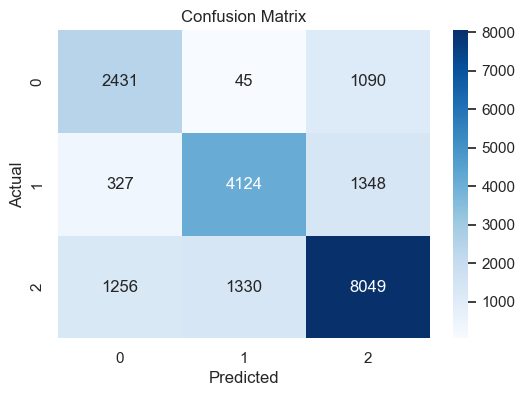

In [932]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
rfi_model = LogisticRegression(random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_model,
                           param_grid=param_grid,
                           cv=5,       # 5-fold cross-validation
                           scoring='accuracy',  # or 'roc_auc' for imbalanced data
                           n_jobs=-1)

# Fit on the RFI-selected features
grid_search.fit(x_train_fs, y_train_res)

# Best parameters
print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)